# NCAA Men's March Madness Factor Importance

This notebook measures how pre-tournament Four Factors and miscellaneous team
statistics contribute to tournament predictions. It compares factor-only
models, calibrates their probabilities, and measures importance only on
future held-out seasons. A second model keeps regular-season power and matchup
signal in separate channels so overall quality cannot erase factor readability.

Tournament seed, KenPom rank, net rating, luck, and adjusted efficiency are
excluded from the factor-only model. A separate baseline uses internally
estimated regular-season scoring efficiency. All inputs come from NCAA
regular-season detailed box scores using KenPom-compatible formulas.

In [1]:
from pathlib import Path
import json
import os
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

from src.run_enhanced_analysis import main as run_analysis
from src.download_ncaa_data import main as download_ncaa_data

REPORTS = PROJECT_ROOT / "reports"
FIGURES = REPORTS / "figures"
PROJECT_ROOT

PosixPath('/Users/edwardluo/Documents/Codex/2026-05-05/create-a-decision-tree-machine-learning')

## Factor Reference

The complete data dictionary below defines each raw factor, its offensive and
defensive direction, its matchup interpretation, and every engineered feature.

In [2]:
display(Markdown((PROJECT_ROOT / "docs" / "factor_reference.md").read_text()))

# Factor Reference

This reference defines every base basketball factor and engineered matchup
concept used by the factor-importance model. The formulas below describe this
project's implementation exactly.

## Enhanced Pre-Tournament Estimates

Every factor now has four supporting estimates built exclusively from detailed
regular-season games:

- **Raw season rate:** the exact aggregate percentage shown in the original
  factor analysis.
- **Reliability-shrunk rate:** the raw numerator and denominator combined with
  a six-game-equivalent season prior. High-opportunity teams remain close to
  their observed rate; low-opportunity teams move toward the season average.
- **Opponent-adjusted rate:** season-specific weighted ridge offense and
  defense effects estimated from every team-game observation, with home court
  controlled explicitly.
- **Recent-form delta:** the final ten games, shrunk toward full-season form
  with a four-game-equivalent prior, minus the full-season estimate.

Game-level standard deviation over those final ten games supplies the
volatility features. A separate opponent-adjusted points-per-100-possession
model supplies regular-season power; it is never included in the factor-only
feature importance model.

The current local data provide 107,634 complete regular-season games from
2003-2023. The available 2024 detailed file ends at day 100 and is excluded by
the completeness audit rather than treated as a pre-tournament snapshot.

## Reading The Features

All percentages are calculated from NCAA regular-season detailed box scores and
multiplied by 100. Tournament games are stored separately and never contribute
to a team's feature snapshot.

Opponent-adjusted rates are converted to within-season percentile strengths
before interaction features are constructed. Exact raw matchup edges remain in
the model as a separate representation:

- `1.00` means one of the strongest values in that season.
- `0.50` is approximately average.
- `0.00` means one of the weakest values in that season.
- Lower-is-better statistics are reversed before percentile ranking.
- A positive matchup feature favors Team A; a negative value favors Team B.

Team A is assigned by a deterministic hash rather than by winner, favorite, or
seed. This prevents the row orientation from leaking the outcome.

## Possession Estimate

Most turnover and steal rates use estimated possessions:

```text
team possessions = FGA + 0.475 * FTA - OR + TO
opponent possessions = opponent FGA + 0.475 * opponent FTA
                       - opponent OR + opponent TO
possessions = (team possessions + opponent possessions) / 2
```

Using the average of both estimates reduces box-score bookkeeping noise.

## Four Factors

### Effective Field-Goal Percentage

**Feature family:** `efg`

```text
Offensive eFG% = 100 * (FGM + 0.5 * 3PM) / FGA
Defensive eFG% = 100 * (opponent FGM + 0.5 * opponent 3PM) / opponent FGA
```

Effective field-goal percentage gives an extra half-make of credit to a made
three because a three is worth 50% more than a two. It captures shooting
accuracy and shot value in one number.

- Higher offensive eFG% is better.
- Lower defensive eFG% allowed is better.
- Offensive strength can reflect shot quality, shooting talent, spacing, and
  finishing.
- Defensive strength can reflect contest quality, rim protection, scheme, and
  forcing inefficient shot locations.

**Strength vs strength:** an elite shooting offense meets a defense that is
elite at suppressing shot value. The result indicates which side's advantage
has historically translated more strongly after accounting for the reverse
matchup.

**Strength vs weakness:** an elite shooting offense meets a defense that allows
high eFG%. This is a favorable efficiency mismatch, but three-point variance can
still make a single-game result volatile.

**Caution:** eFG% describes outcomes, not the exact shot-quality process. Two
teams can have the same eFG% with very different three-point volume and rim-shot
profiles.

### Turnover Percentage

**Feature family:** `turnover`

```text
Offensive TO% = 100 * team turnovers / possessions
Defensive TO% = 100 * opponent turnovers / possessions
```

Turnover percentage estimates how frequently a possession ends without a shot
or free-throw opportunity.

- Lower offensive TO% is better because the offense protects possessions.
- Higher defensive TO% is better because the defense ends opponent possessions.
- The separate steal and non-steal-turnover factors explain how those turnovers
  occur.

**Strength vs strength:** a low-turnover offense faces a high-turnover defense.
This is a direct contest between ball security and disruption.

**Strength vs weakness:** a careful offense faces a defense that rarely forces
turnovers, or a disruptive defense faces a careless offense. The second case
can create transition chances in addition to denying shots.

**Caution:** turnover rates depend on style and opponent pressure. A team can
accept more turnovers while creating higher-value shots on its successful
possessions.

### Offensive Rebounding Percentage

**Feature family:** `offensive_rebound`

```text
Offensive OR% = 100 * team OR / (team OR + opponent DR)
Defensive OR% allowed = 100 * opponent OR / (opponent OR + team DR)
```

Offensive rebounding percentage estimates the share of available offensive
rebounds captured. The defensive version measures the share conceded.

- Higher offensive OR% is better.
- Lower defensive OR% allowed is better.
- Offensive strength creates second-chance possessions and can draw fouls.
- Defensive strength finishes stops and limits repeated shot attempts.

**Strength vs strength:** an elite offensive rebounding team meets an elite
defensive rebounding team. This is the clearest example of a direct Four Factors
collision.

**Strength vs weakness:** a strong offensive rebounding team faces a poor
defensive rebounding team. The offense may gain extra attempts even if its
first-shot efficiency is ordinary.

**Caution:** teams that prioritize transition defense may intentionally send
fewer players to the offensive glass. OR% therefore reflects both ability and
strategic choice.

### Free-Throw Rate

**Feature family:** `free_throw_rate`

```text
Offensive FTRate = 100 * FTA / FGA
Defensive FTRate allowed = 100 * opponent FTA / opponent FGA
```

Free-throw rate measures how frequently a team earns free-throw attempts
relative to field-goal attempts.

- Higher offensive FTRate is better in the model's directional ranking.
- Lower defensive FTRate allowed is better.
- Offensive strength often reflects rim pressure, physicality, and foul drawing.
- Defensive strength reflects defending without fouling.

**Strength vs strength:** a foul-drawing offense faces a defense that avoids
fouls. The matchup can depend heavily on personnel, officiating, and whether the
offense reaches the paint.

**Strength vs weakness:** a high-FTRate offense faces a foul-prone defense,
creating a potential efficiency and lineup-depth advantage.

**Caution:** this implementation uses attempts divided by field-goal attempts.
It does not directly include free-throw accuracy, which is modeled separately.

## Miscellaneous Shooting Factors

### Three-Point Percentage

**Feature family:** `three_point`

```text
Offensive 3P% = 100 * 3PM / 3PA
Defensive 3P% allowed = 100 * opponent 3PM / opponent 3PA
```

- Higher offensive 3P% is better.
- Lower defensive 3P% allowed is better.
- It isolates perimeter conversion from two-point shooting.

**Matchup meaning:** strength vs strength compares elite perimeter shooting with
elite suppression. Strength vs weakness identifies an offense capable of
punishing a defense that has allowed efficient three-point shooting.

**Caution:** three-point percentage is volatile in small samples, and defensive
3P% can contain more shooting luck than statistics such as attempt location or
contest quality.

### Two-Point Percentage

**Feature family:** `two_point`

```text
2PM = FGM - 3PM
2PA = FGA - 3PA
Offensive 2P% = 100 * 2PM / 2PA
Defensive 2P% allowed = 100 * opponent 2PM / opponent 2PA
```

- Higher offensive 2P% is better.
- Lower defensive 2P% allowed is better.
- It combines rim finishing, post play, and midrange shooting.

**Matchup meaning:** strength vs strength often represents finishing against rim
protection or disciplined interior defense. Strength vs weakness can expose a
defense that struggles to protect the paint.

**Caution:** without shot-location data, the factor cannot distinguish rim
attempts from midrange attempts.

### Free-Throw Percentage

**Feature family:** `free_throw_pct`

```text
Offensive FT% = 100 * FTM / FTA
Defensive opponent FT% = 100 * opponent FTM / opponent FTA
```

- Higher offensive FT% is better.
- Lower opponent FT% is treated as stronger defense for consistent directional
  feature construction.
- Offensive FT% helps determine whether foul drawing becomes actual scoring.

**Matchup meaning:** offensive FT% is largely a team skill rather than a direct
interaction with the opponent. The defensive value should be interpreted with
care because defenses have limited control over opponent free-throw accuracy.

**Caution:** defensive opponent FT% may mostly reflect opponent mix and random
variation. A low importance estimate is therefore unsurprising.

## Miscellaneous Ball-Security Factors

### Block Rate

**Feature family:** `block`

```text
Offensive block rate = 100 * opponent blocks / team 2PA
Defensive block rate = 100 * team blocks / opponent 2PA
```

The offensive version measures how often a team's two-point attempts are
blocked; the defensive version measures rim disruption.

- Lower offensive block rate is better.
- Higher defensive block rate is better.

**Strength vs strength:** an offense that rarely gets blocked faces an elite
shot-blocking defense. **Strength vs weakness:** a strong rim-protecting defense
faces an offense whose two-point attempts are blocked frequently.

**Caution:** blocks capture only some rim deterrence. Great interior defenders
can alter or discourage attempts without recording a block.

### Steal Rate

**Feature family:** `steal`

```text
Offensive steal rate allowed = 100 * opponent steals / possessions
Defensive steal rate = 100 * team steals / possessions
```

- Lower offensive steal rate allowed is better.
- Higher defensive steal rate is better.
- Steals are especially valuable because they often create transition offense.

**Strength vs strength:** a secure offense faces an aggressive defense that
creates live-ball turnovers. **Strength vs weakness:** a high-steal defense
faces a team vulnerable to ball pressure.

**Caution:** aggressive steal attempts can also create defensive breakdowns;
the rate does not directly measure that tradeoff.

### Non-Steal Turnover Rate

**Feature family:** `nonsteal_turnover`

```text
Offensive non-steal TO% = 100 * max(team TO - opponent steals, 0) / possessions
Defensive non-steal TO% = 100 * max(opponent TO - team steals, 0) / possessions
```

This separates dead-ball and uncredited turnovers from steals. Examples include
travels, offensive fouls, shot-clock violations, and passes out of bounds.

- Lower offensive non-steal TO% is better.
- Higher defensive non-steal TO% is treated as better.

**Matchup meaning:** it helps distinguish general ball security from specific
vulnerability to steals. A strength-vs-weakness edge can indicate an offense
that avoids unforced mistakes against a defense that creates few non-steal
turnovers, or the reverse.

**Caution:** subtracting steals is a box-score approximation; turnover and steal
bookkeeping do not always map perfectly one to one.

## Miscellaneous Creation And Style Factors

### Assist Rate

**Feature family:** `assist`

```text
Offensive assist rate = 100 * team assists / team FGM
Defensive assist rate allowed = 100 * opponent assists / opponent FGM
```

- Higher offensive assist rate is treated as stronger creation.
- Lower opponent assist rate is treated as stronger defense.
- It describes how often made baskets are assisted, not total passing quality.

**Matchup meaning:** strength vs strength compares a high-assist offense with a
defense that suppresses assisted baskets. Strength vs weakness can identify a
passing offense facing a defense prone to losing structure.

**Caution:** assist rate is strongly affected by scorekeeper conventions,
offensive system, and shot mix. Isolation-heavy teams can be excellent offenses
with modest assist rates.

### Three-Point Attempt Rate

**Feature family:** `three_point_rate`

```text
Offensive 3PA rate = 100 * team 3PA / team FGA
Defensive 3PA rate allowed = 100 * opponent 3PA / opponent FGA
```

Three-point attempt rate is treated as style, not as inherently good or bad. Its
within-season percentile measures how perimeter-oriented a team or its opponent
shot profile is.

- High offensive rate means a larger share of shots are threes.
- High defensive rate means opponents take a larger share of shots from three.
- `three_point_rate_environment` measures the overall likelihood that a matchup
  will be three-point heavy.
- `three_point_leverage_edge` increases the impact of a three-point efficiency
  advantage when the matchup is expected to generate high three-point volume.

**Caution:** volume creates both scoring upside and single-game variance. A high
attempt rate is not automatically a strength.

## Per-Factor Engineered Matchup Features

For every strength-based factor above, let:

- `A_off` = Team A offensive strength percentile.
- `A_def` = Team A defensive strength percentile.
- `B_off` = Team B offensive strength percentile.
- `B_def` = Team B defensive strength percentile.

The model creates the following features for each factor.

### Raw Matchup Edge

```text
A attack = direction-adjusted Team A offense
           - direction-adjusted Team B defense
B attack = direction-adjusted Team B offense
           - direction-adjusted Team A defense
raw matchup edge = A attack - B attack
raw matchup environment = (A attack + B attack) / 2
```

This directly compares each offense with the opposing defense. The direction is
reversed for lower-is-better rates, so a positive value always favors Team A.
It preserves the original percentage-point scale, while percentile interactions
describe relative standing within a season. The model intentionally contains no
offense-vs-offense or defense-vs-defense comparison features.

The environment term preserves whether both cross-matchups are generally
favorable or unfavorable. It lets nonlinear models treat the same directional
edge differently in a high-offense or low-offense environment without adding
same-side comparisons.

### Offensive Strength Difference

```text
A_off - B_off
```

Compares the teams' offensive ability in the same factor without considering
the opposing defenses.

### Defensive Strength Difference

```text
A_def - B_def
```

Compares the teams' defensive ability in the same factor.

### Overall Strength Difference

```text
(A_off + A_def - B_off - B_def) / 2
```

Summarizes two-way strength in that factor.

### Net Matchup Edge

```text
(A_off - B_def) - (B_off - A_def)
```

Compares Team A's offensive matchup with Team B's offensive matchup. Positive
values indicate the factor-level matchup favors Team A on balance.

### Matchup Environment

```text
Team A matchup = A_off - B_def
Team B matchup = B_off - A_def
(Team A matchup + Team B matchup) / 2
```

This symmetric term measures whether both offenses face generally favorable or
unfavorable opposition in the factor. It has no winner direction by itself, but
nonlinear models can use it to condition the directional edge.

### Net Strength Vs Strength

```text
A_off * B_def - B_off * A_def
```

Emphasizes games in which strong offense meets strong defense, then compares
that collision with the reverse side of the matchup.

### Net Strength Vs Weakness

```text
A_off * (1 - B_def) - B_off * (1 - A_def)
```

Emphasizes opportunities for a strong offense to attack a weak defense.

### Net Weakness Vs Strength

```text
(1 - A_off) * B_def - (1 - B_off) * A_def
```

Emphasizes cases in which an offensive weakness runs into an opposing defensive
strength.

## Three-Point Style Features

Because three-point attempt rate is a neutral style variable, it uses different
transformations:

- `off_style_diff`: difference between offensive 3PA-rate percentiles.
- `def_style_diff`: difference between defensive 3PA-rate-allowed percentiles.
- `expected_diff`: difference in each team's expected three-point environment.
- `environment`: average of both teams' offensive and defensive 3PA-rate
  percentiles; high values indicate a three-point-heavy matchup.

## Composite Features

### Four Factor Edge Mean

The average net matchup edge across eFG%, turnover percentage, offensive
rebounding percentage, and free-throw rate. It estimates broad matchup quality.

### Four Factor Edge Minimum And Maximum

The weakest and strongest of the four net matchup edges. The minimum captures a
potential vulnerability; the maximum captures a standout advantage.

### Four Factor Edge Standard Deviation

The dispersion of the four matchup edges. A high value means the matchup is
uneven, with pronounced strengths and weaknesses rather than a uniform edge.

### Four Factor Positive Edge Count

The number of positive Four Factor edges minus the number of negative edges. It
ranges from `-4` to `4` and measures breadth of matchup advantages.

### Possession Creation Edge

The average turnover and offensive-rebounding net edges. It summarizes which
team is more likely to create extra shot opportunities.

### Shooting Pressure Edge

The average eFG% and free-throw-rate net edges. It combines shot efficiency with
the ability to pressure the defense and reach the line.

### Perimeter Edge

The average eFG% and three-point-percentage net edges. It summarizes shooting
value with an emphasis on perimeter conversion.

### Interior Edge

The average two-point, offensive-rebounding, free-throw-rate, and block-rate net
edges. It represents paint scoring, second chances, foul pressure, and rim
protection together.

### Ball Security Edge

The average overall turnover, steal, and non-steal-turnover net edges. It
separates possession protection and disruption into related components.

### Strength Vs Strength Composite

The average net strength-vs-strength term across all Four Factors and
miscellaneous strength factors.

### Weakness Exploitation Composite

The average net strength-vs-weakness term across all Four Factors and
miscellaneous strength factors.

### Three-Point Leverage Edge

```text
three-point net matchup edge * three-point-rate environment
```

This gives more weight to a perimeter-efficiency advantage when both teams'
profiles suggest that many shots will come from three.

## Interpreting Importance

The individual chart reports the increase in held-out log loss after shuffling
one feature within each validation season. The grouped chart shuffles all
features belonging to a basketball concept together.

- Larger positive importance means the fitted model relied more on the feature.
- Near-zero importance means the feature added little unique held-out signal.
- Negative importance can occur when noise or correlation makes a feature
  slightly harmful on a particular sample.
- Correlated features share predictive credit, so exact individual rankings can
  understate the importance of a broader concept.
- Importance is not causality. It does not prove that changing a factor by a
  specified amount will cause a corresponding change in win probability.
- Stability across held-out seasons and agreement across model families are more
  trustworthy than a single importance estimate.


## 1. Prepare NCAA Data

Raw data are downloaded only when required files are missing. They remain
excluded from Git.

In [3]:
required_files = [
    PROJECT_ROOT / "data/raw/MTeams.csv",
    PROJECT_ROOT / "data/raw/MNCAATourneyCompactResults.csv",
    PROJECT_ROOT / "data/raw/MNCAATourneySeeds.csv",
    PROJECT_ROOT / "data/raw/MRegularSeasonDetailedResults.csv",
]

if not all(path.exists() for path in required_files):
    download_ncaa_data()
else:
    print("NCAA source files already available.")

NCAA source files already available.


## 2. Build Features, Train Models, And Validate

This single entry point rebuilds the pre-tournament team features, engineers
matchup variables, compares and calibrates all candidate models, and writes
the model and reports.

In [4]:
run_analysis()

metrics = json.loads((REPORTS / "metrics.json").read_text())
comparison = pd.read_csv(REPORTS / "model_comparison.csv")
power_metrics = json.loads((REPORTS / "power_matchup_metrics.json").read_text())
power_comparison = pd.read_csv(REPORTS / "power_matchup_model_comparison.csv")

print("Selected model:", metrics["selected_model"])
print("Pre-tournament timing:", metrics["snapshot_status"])
print("Importance gate passed:", metrics["trustworthiness"]["importance_gate_passed"])
comparison

Wrote data/processed/pretournament_team_factors.csv with 7,255 team-seasons
Confirmed pre-tournament seasons: 2003-2023
Excluded incomplete seasons: {'2024': 100}


{
  "selected_model": "regularized_logistic",
  "metrics": {
    "raw_accuracy": 0.6633416458852868,
    "raw_brier": 0.213060257142454,
    "raw_log_loss": 0.6217672274232393,
    "raw_roc_auc": 0.7311060251753818,
    "calibrated_accuracy": 0.6608478802992519,
    "calibrated_brier": 0.21220738079089155,
    "calibrated_log_loss": 0.616018894279835,
    "calibrated_roc_auc": 0.7311060251753818,
    "training_cv_accuracy": 0.6595744680851063,
    "training_cv_brier": 0.20392355833296724,
    "training_cv_log_loss": 0.585286964190194,
    "training_cv_roc_auc": 0.7461660057128594
  },
  "trustworthiness": {
    "importance_gate_passed": true,
    "selection_accuracy_auc_gate_passed": true,
    "validation_used_for_model_family_selection": false,
    "final_untouched_test_set_available": false,
    "accuracy_wilson_95": [
      0.6131792704259504,
      0.7054638729664282
    ],
    "stable_features_in_top_15": 12,
    "minimum_stability_definition": "positive permutation importance in 

{
  "architecture": "separate regular-season power and Four Factors matchup channels",
  "power_source": "opponent-adjusted scoring efficiency from regular-season detailed games",
  "factor_source": "opponent-adjusted, reliability-shrunk Four Factors and miscellaneous rates",
  "kenpom_rank_used": false,
  "regular_season_games_used": 107634,
  "train_seasons": [
    2003,
    2004,
    2005,
    2006,
    2007,
    2008,
    2009,
    2010,
    2011,
    2012,
    2013,
    2014,
    2015,
    2016
  ],
  "held_out_seasons": [
    2017,
    2018,
    2019,
    2021,
    2022,
    2023
  ],
  "factor_features": 98,
  "factor_tuning": [
    {
      "configuration": "C=0.01",
      "cv_log_loss": 0.581088420862228
    }
  ],
  "power_tuning": [
    {
      "configuration": "C=0.25",
      "cv_log_loss": 0.5603133760806197
    }
  ],
  "stacker": {
    "intercept": -0.004134650722228364,
    "power_coefficient": 0.8371288234347612,
    "factor_coefficient": 0.09043280404289969
  },
  "hel

,model,raw_accuracy,raw_brier,raw_log_loss,raw_roc_auc,calibrated_accuracy,calibrated_brier,calibrated_log_loss,calibrated_roc_auc,training_cv_accuracy,training_cv_brier,training_cv_log_loss,training_cv_roc_auc
0,hist_gradient_boosting,0.680798,0.210222,0.612264,0.735285,0.678304,0.209112,0.606488,0.735285,0.668693,0.215335,0.621485,0.730460
1,random_forest,0.663342,0.210004,0.608851,0.731753,0.663342,0.210117,0.608903,0.731753,0.674772,0.206401,0.597125,0.738872
2,soft_voting_ensemble,0.658354,0.214818,0.622634,0.721056,0.665835,0.212263,0.614628,0.731405,0.664134,0.207640,0.598215,0.737227
3,regularized_logistic,0.663342,0.213060,0.621767,0.731106,0.660848,0.212207,0.616019,0.731106,0.659574,0.203924,0.585287,0.746166
4,decision_tree,0.608479,0.266612,0.923597,0.635703,0.608479,0.239088,0.688473,0.635703,0.613982,0.248898,0.778521,0.673004


## 3. Regular-Season Data Contribution

Every complete regular-season game contributes two team-game scoring
observations for opponent adjustment, reliability shrinkage, recent form,
volatility, and the separate scoring-power baseline. Tournament outcomes
remain the only binary labels used to fit and evaluate the tournament
classifier, avoiding leakage from a game's own final box score.

In [5]:
print("Regular-season games used:", f"{power_metrics['regular_season_games_used']:,}")
print("KenPom rank used:", power_metrics["kenpom_rank_used"])
power_comparison

Regular-season games used: 107,634
KenPom rank used: False


,model,accuracy,brier,log_loss,roc_auc
0,two_channel_stack,0.653367,0.209199,0.602377,0.729514
1,regular_season_power_only,0.658354,0.210989,0.606483,0.727474
2,factor_only,0.655860,0.211704,0.615083,0.731678


## 4. Feature Importance

Bars show the held-out increase in log loss when each feature is shuffled
within a validation season. Whiskers capture uncertainty across seasons and
repeated shuffles. Larger positive values indicate greater predictive reliance.

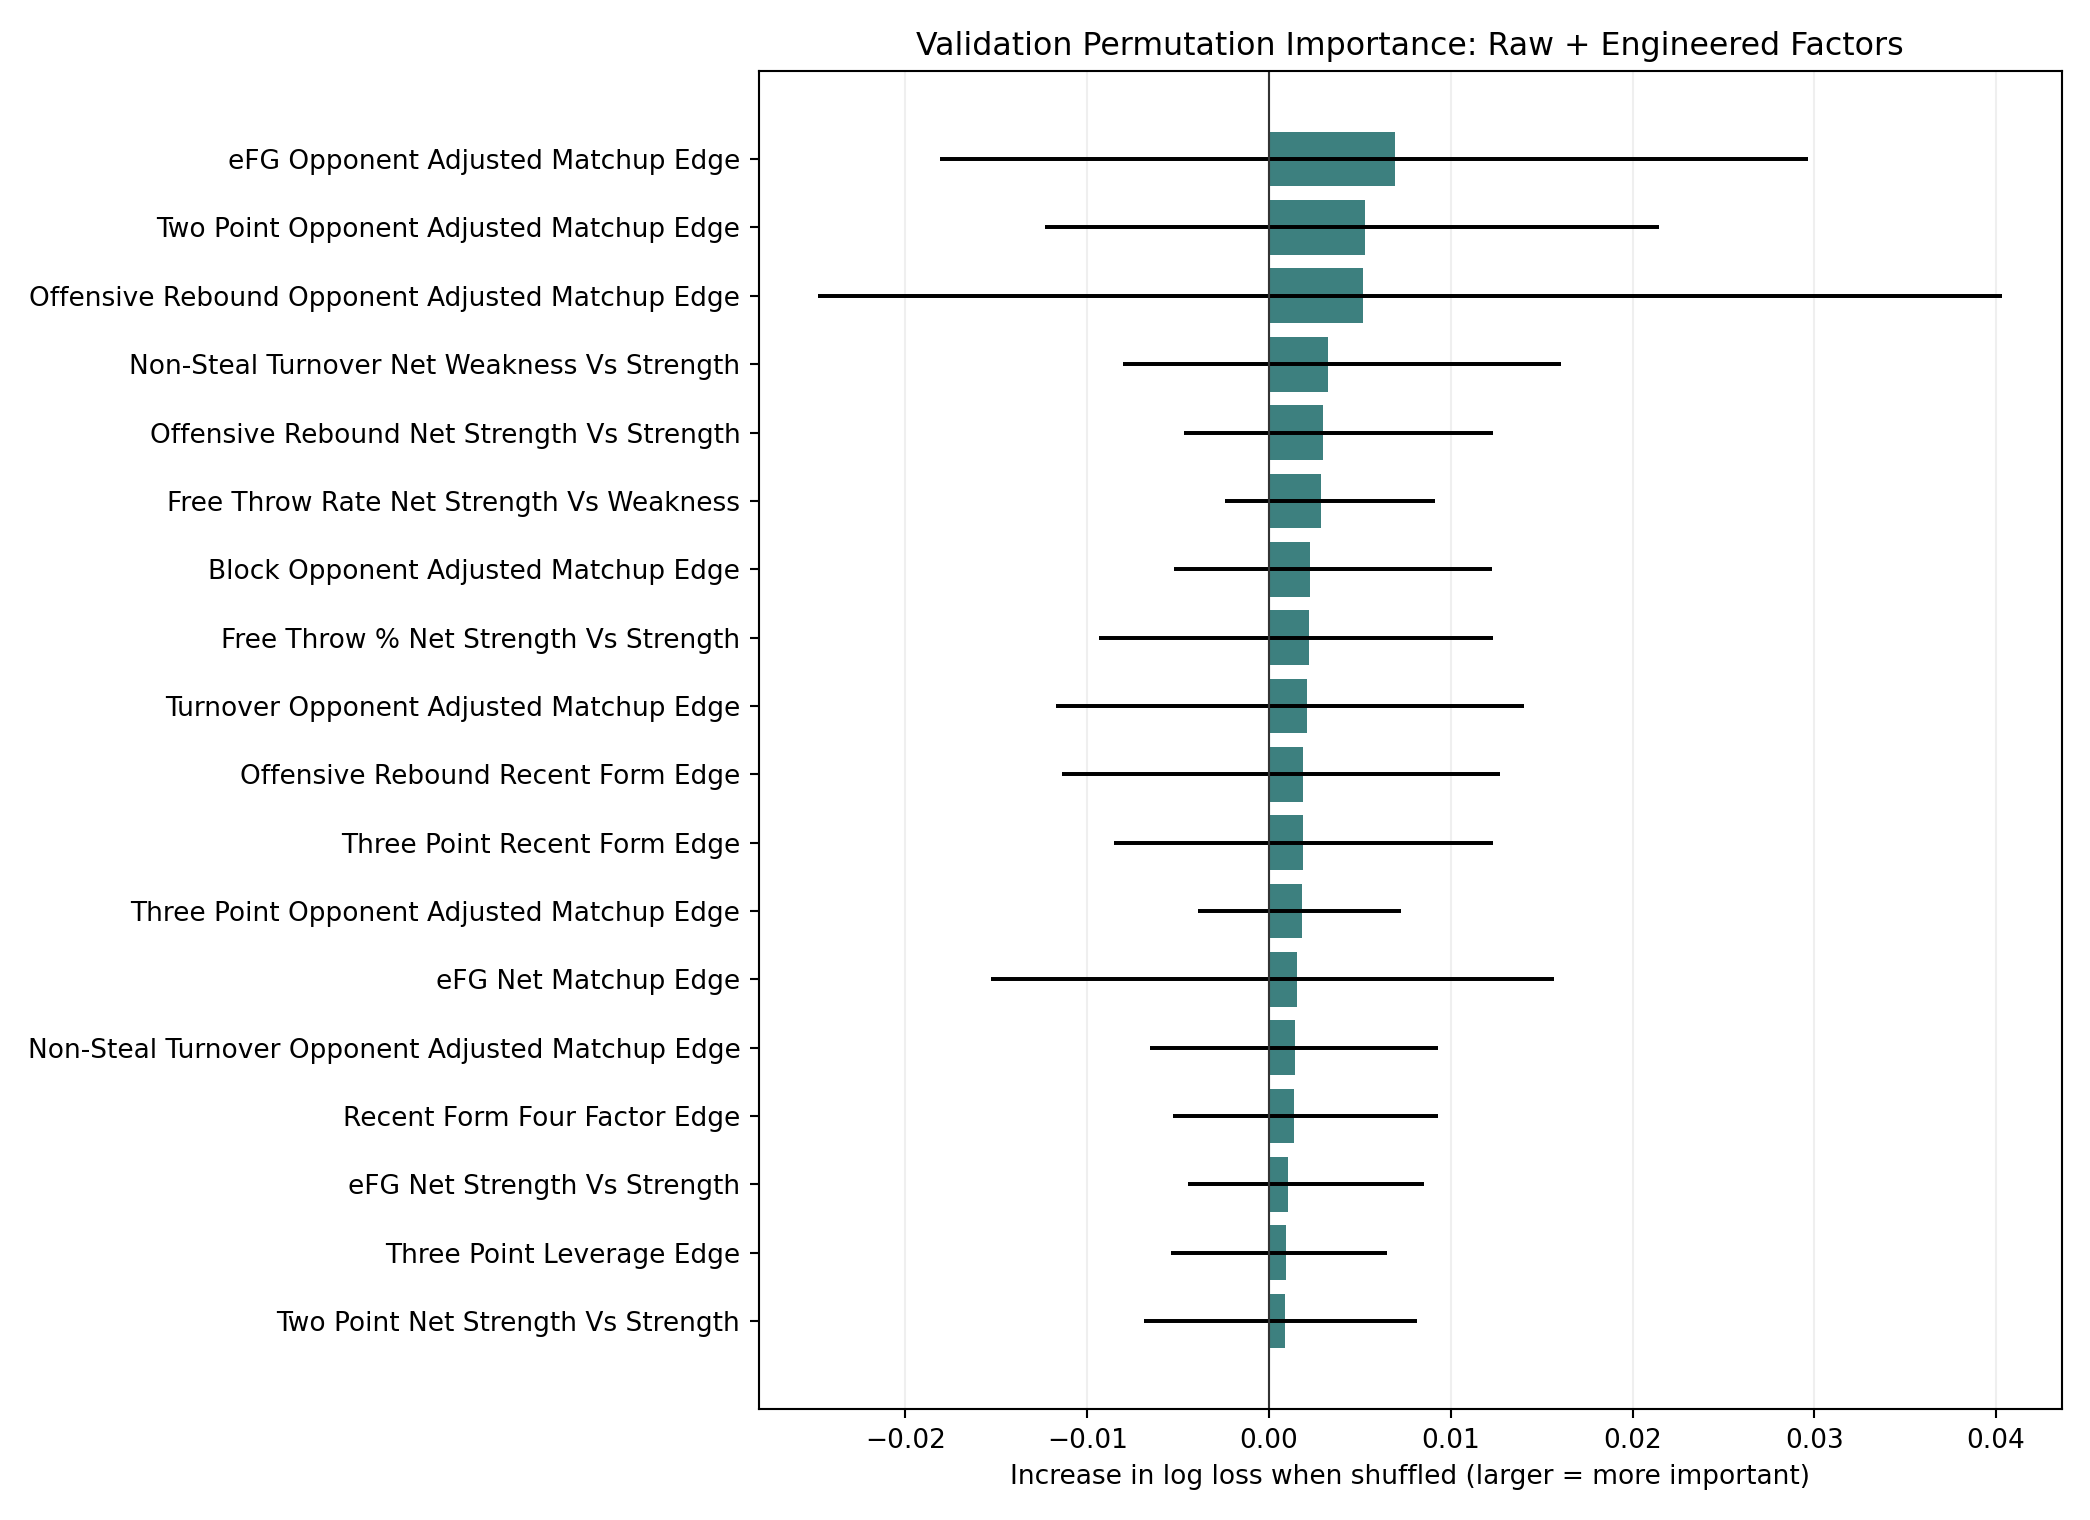

In [6]:
display(Image(filename=str(FIGURES / "feature_importance.png")))

## 5. Grouped Factor Importance

Correlated engineered variables can split credit. This chart shuffles each
basketball concept as a block and shows its importance range across logistic
regression, decision tree, random forest, and gradient boosting.

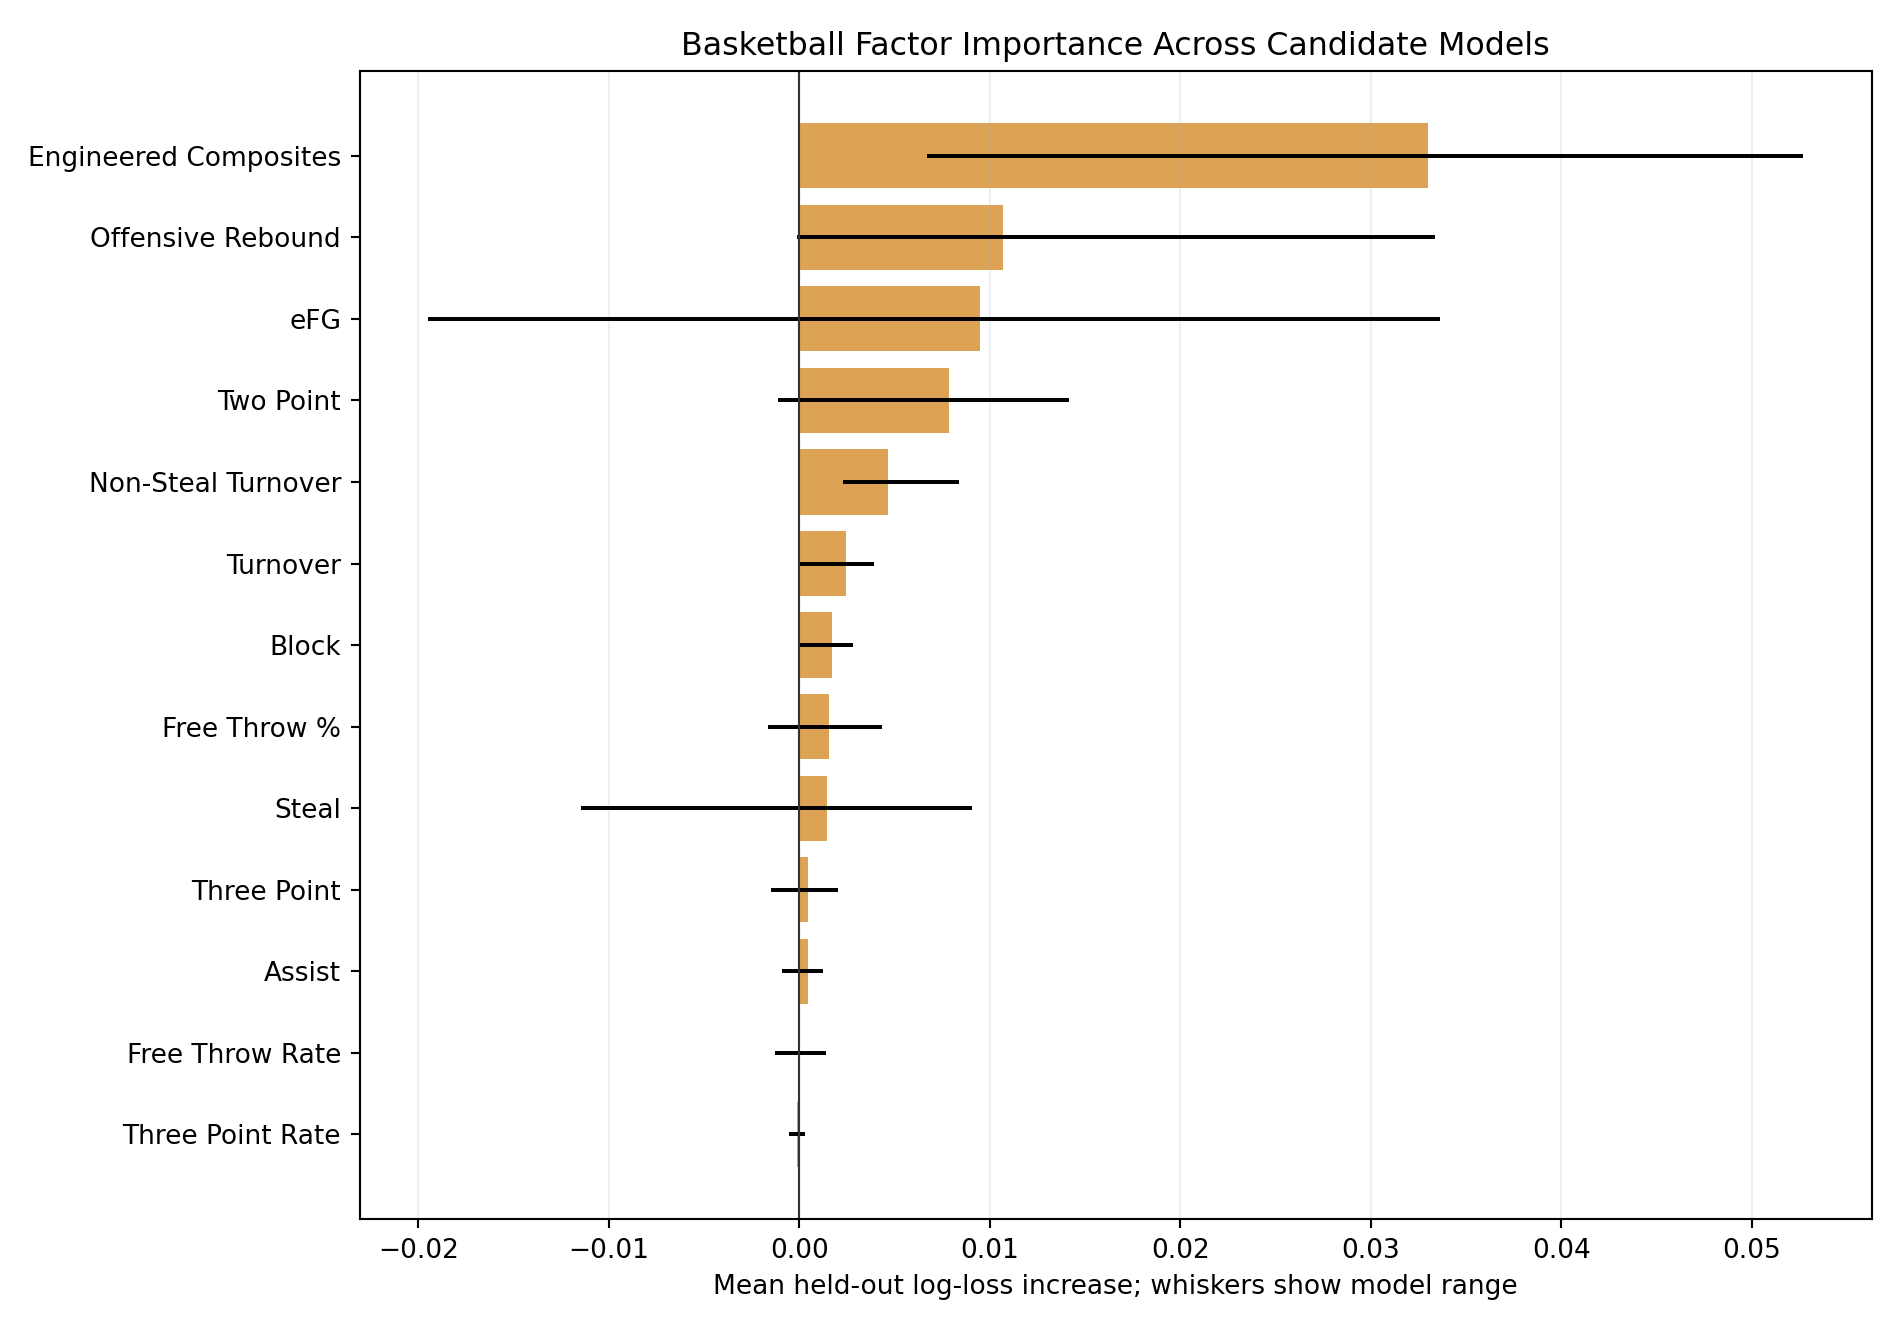

In [7]:
display(Image(filename=str(FIGURES / "group_importance.png")))

## 6. Raw Rates And Matchup Mechanisms

This view directly compares raw offense-vs-opposing-defense matchup edges,
strength-vs-strength, strength-vs-weakness, and the remaining engineered
mechanisms. No feature compares offense only with offense or defense only
with defense.

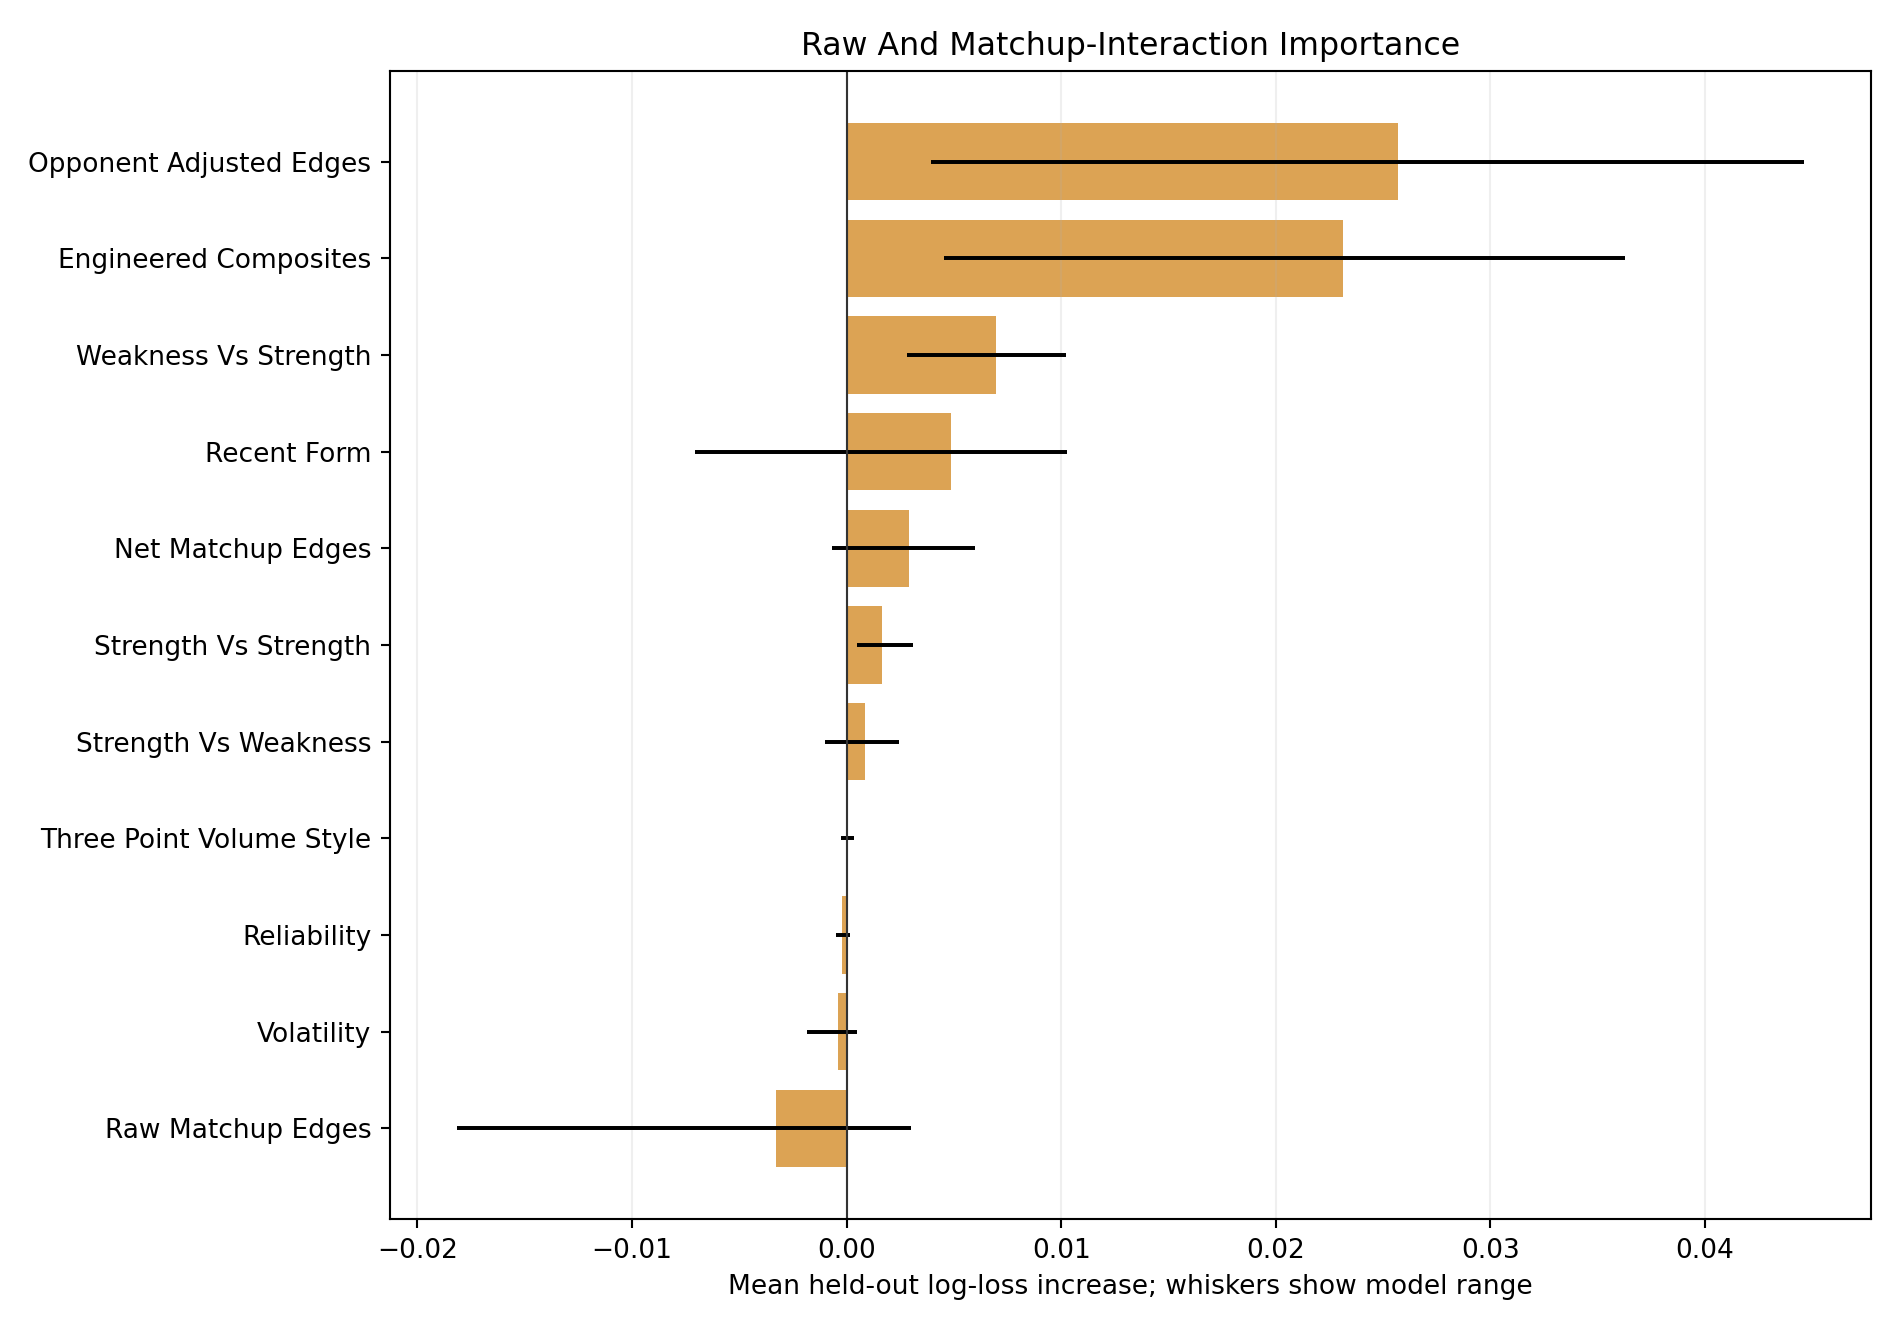

In [8]:
display(Image(filename=str(FIGURES / "interaction_importance.png")))

## 7. Model Diagnostics

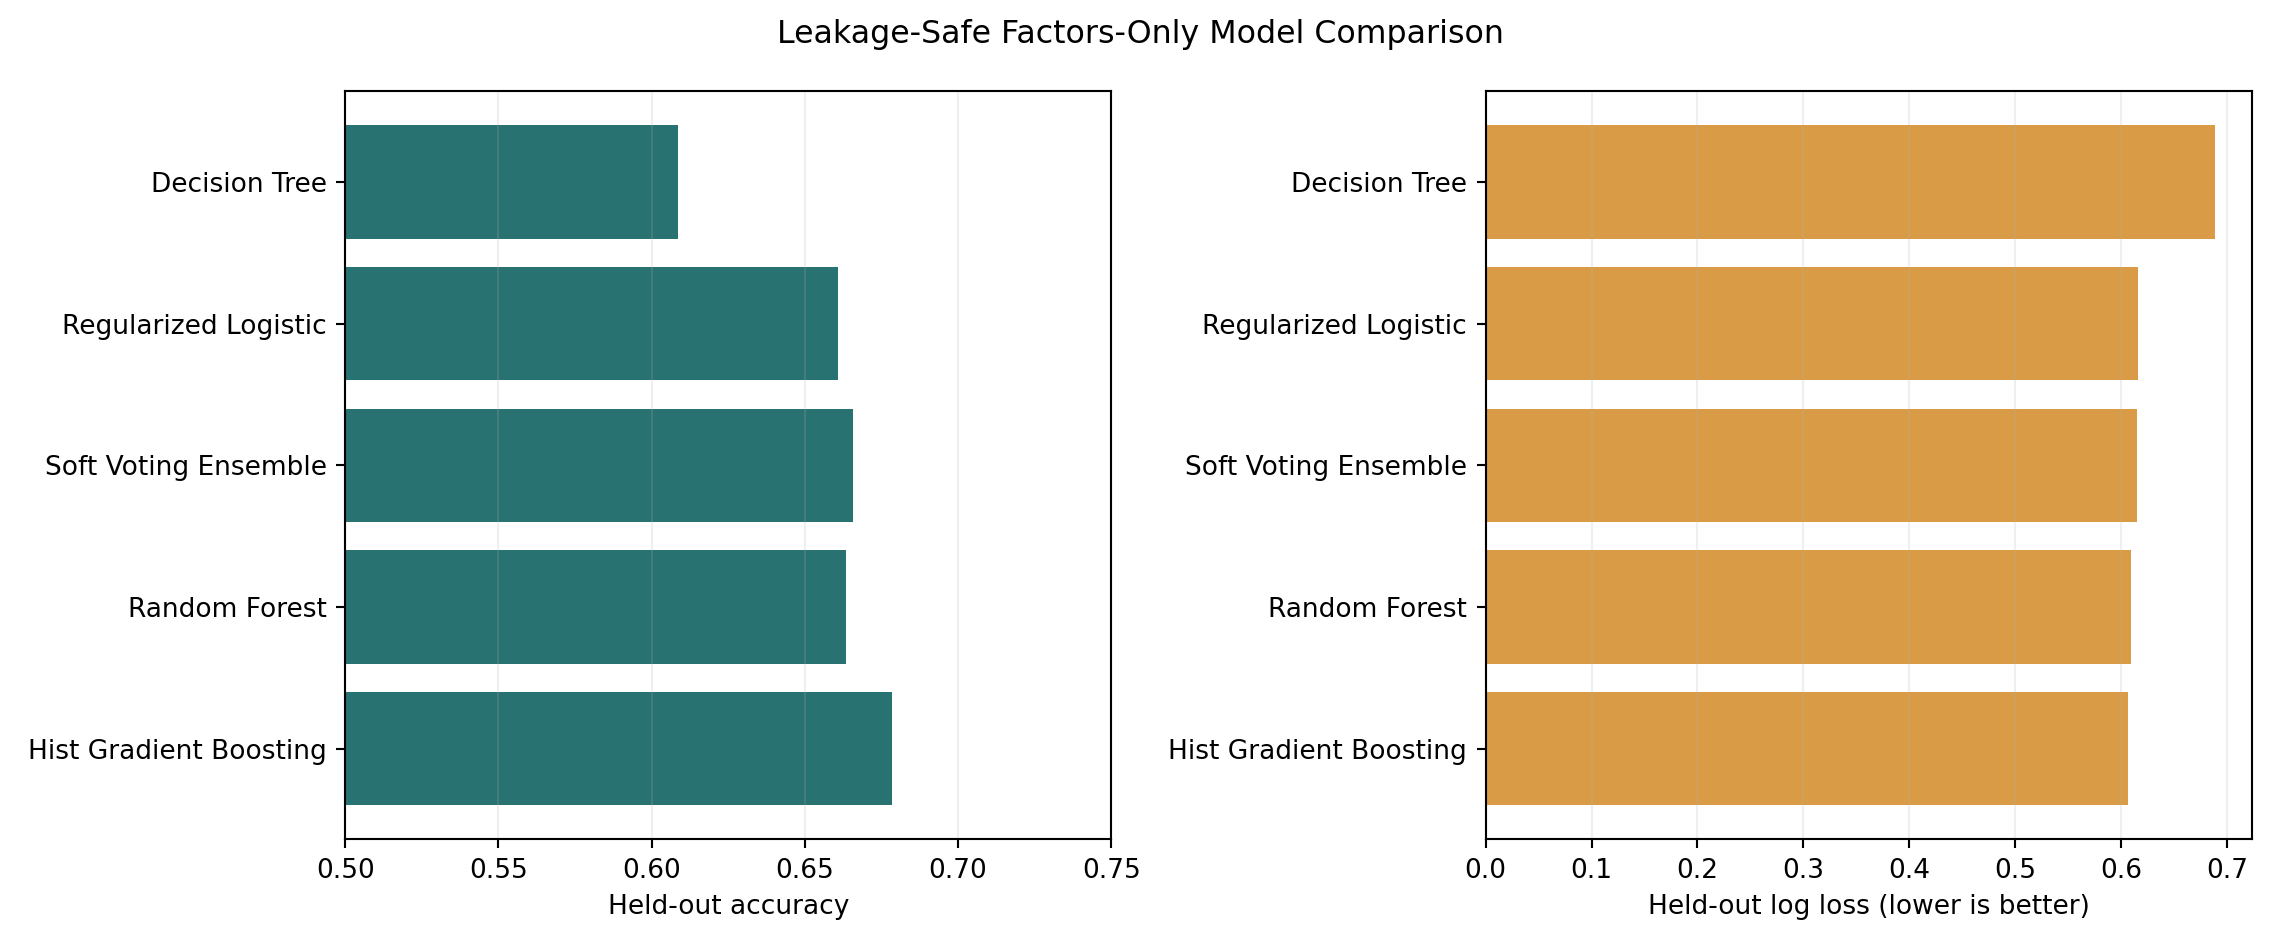

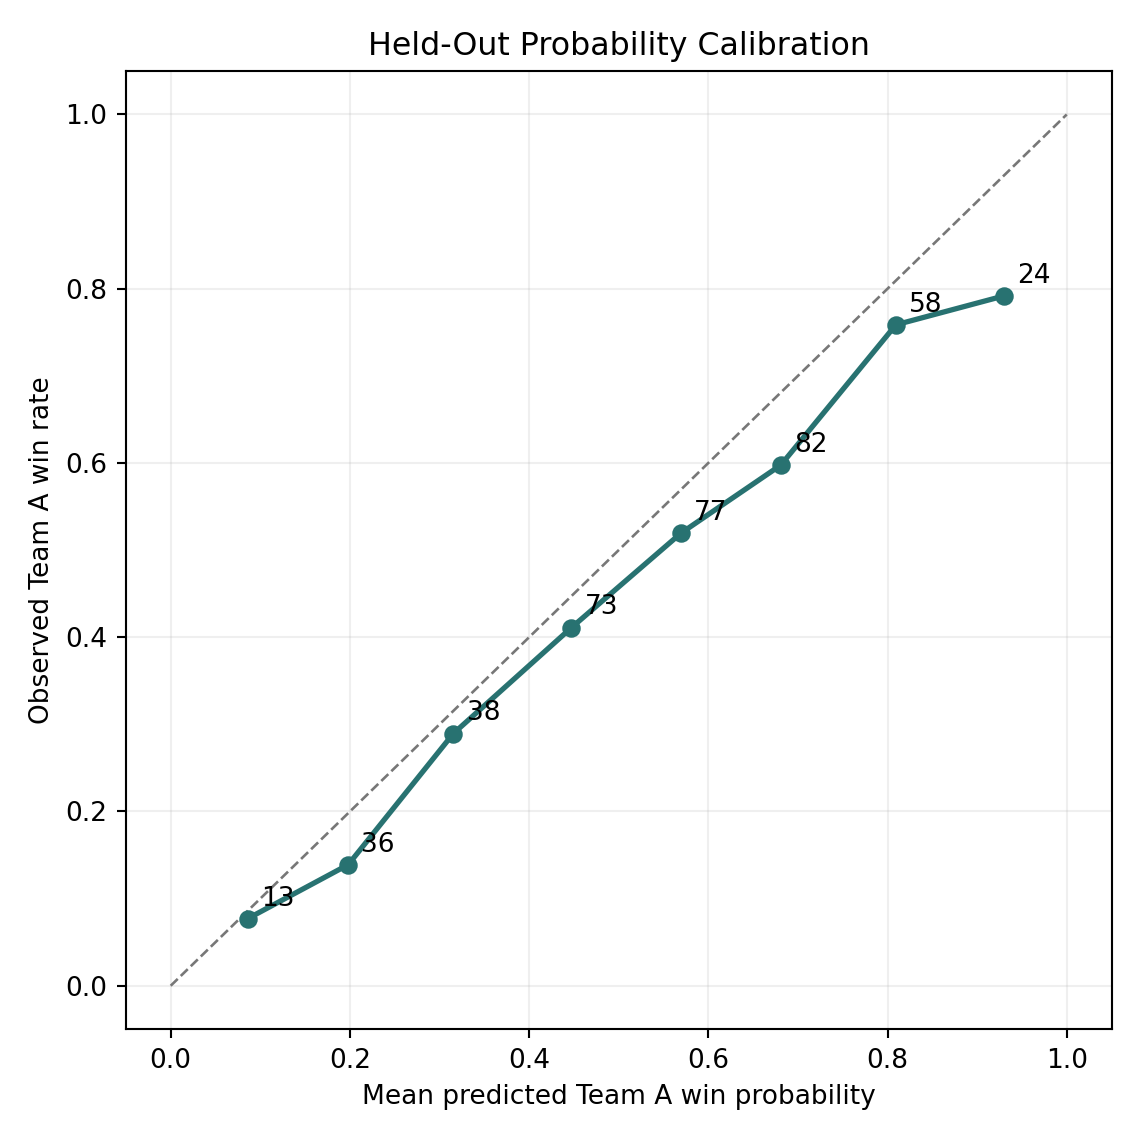

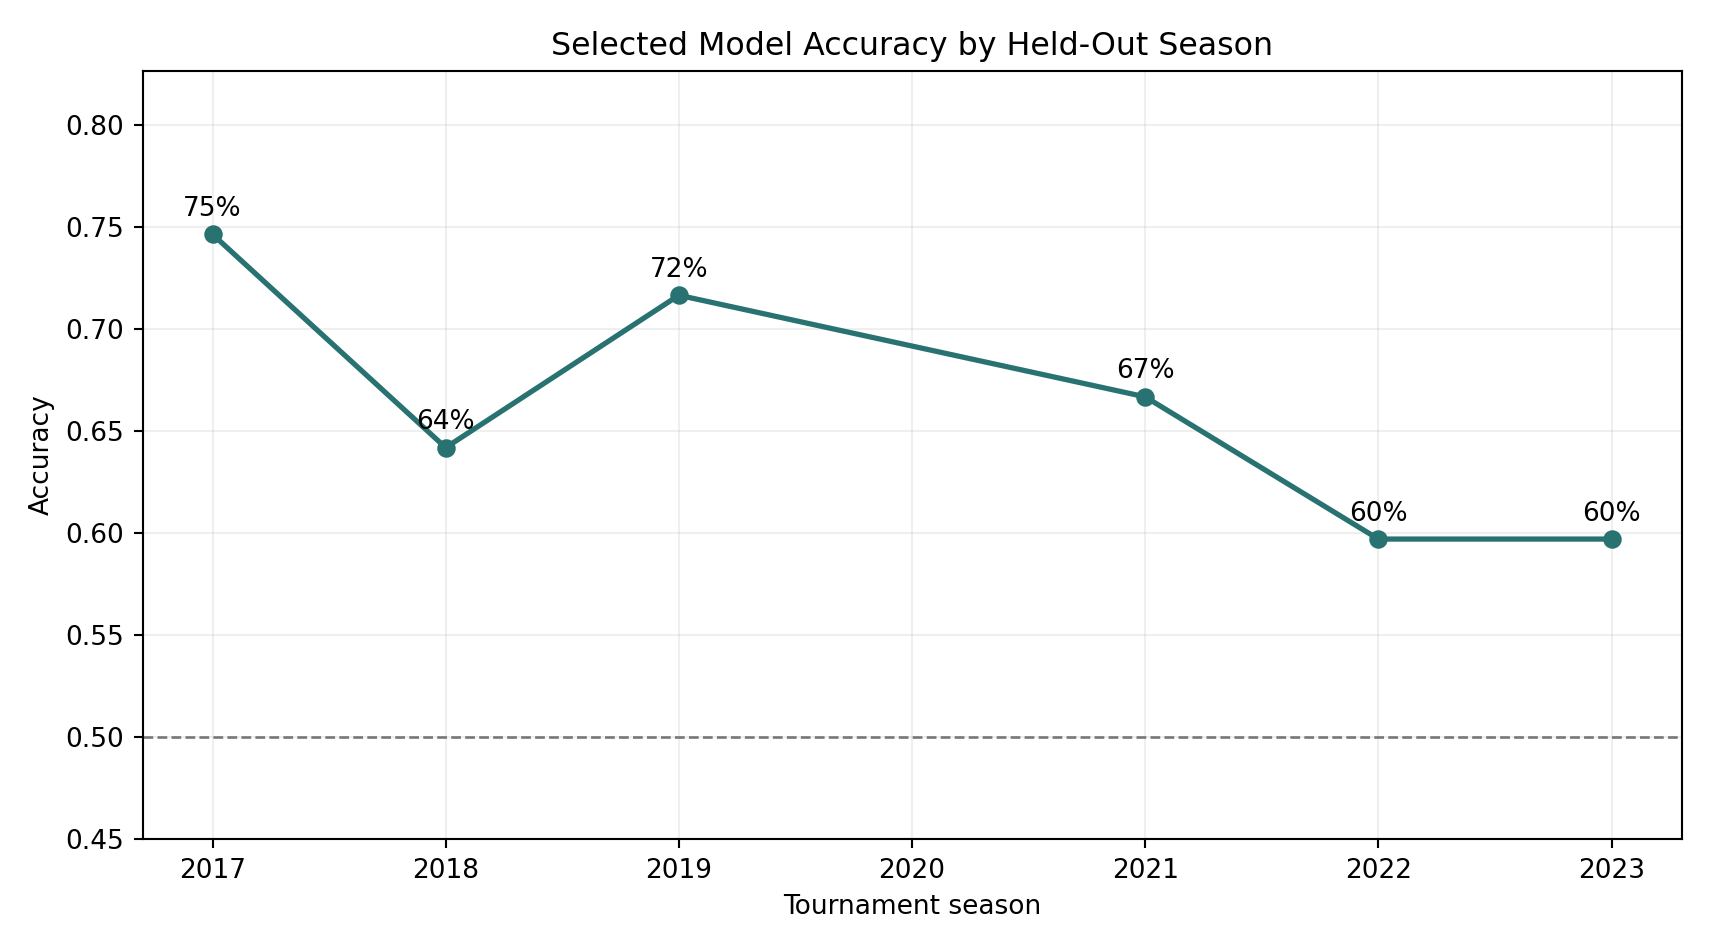

In [9]:
display(Image(filename=str(FIGURES / "model_comparison.png")))
display(Image(filename=str(FIGURES / "calibration.png")))
display(Image(filename=str(FIGURES / "accuracy_by_year.png")))

## 8. Power Baseline And Conditional Matchup Signal

The factor-only model remains the interpretation model. The two-channel stack
combines it with opponent-adjusted regular-season scoring power. Conditional
permutation importance shuffles factor groups while the power baseline stays
fixed.

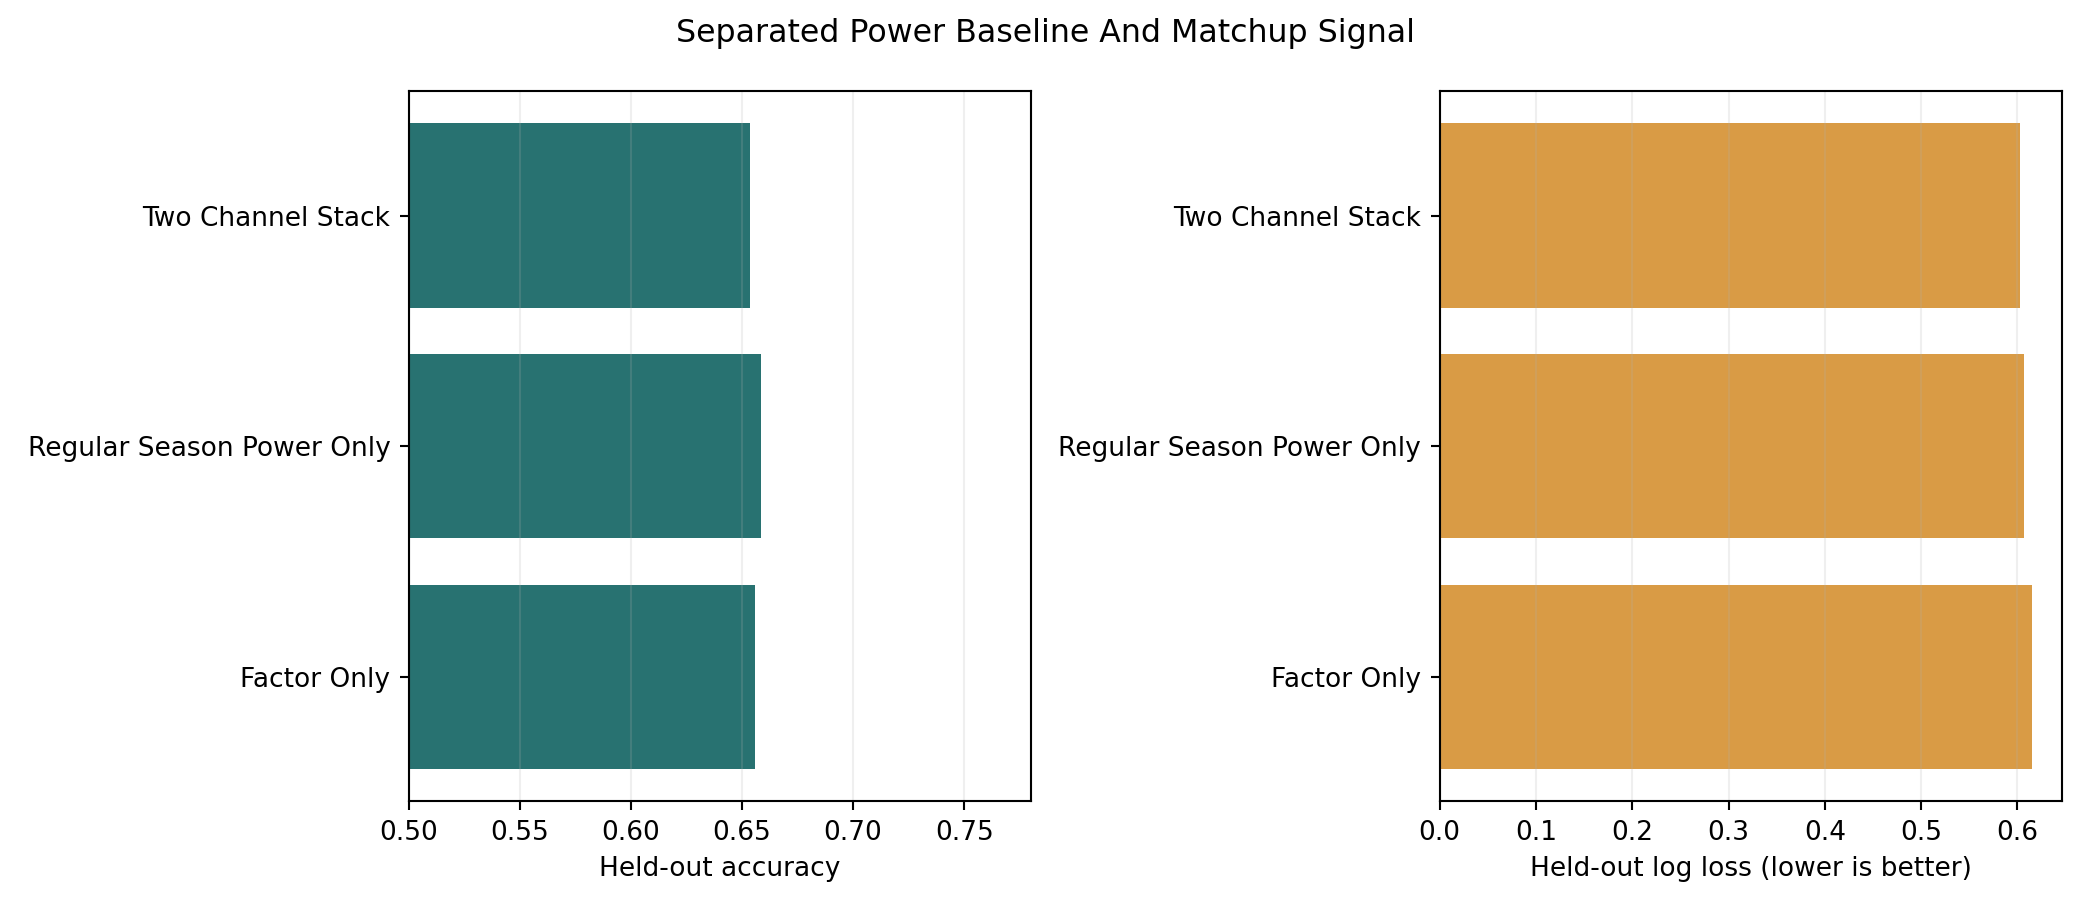

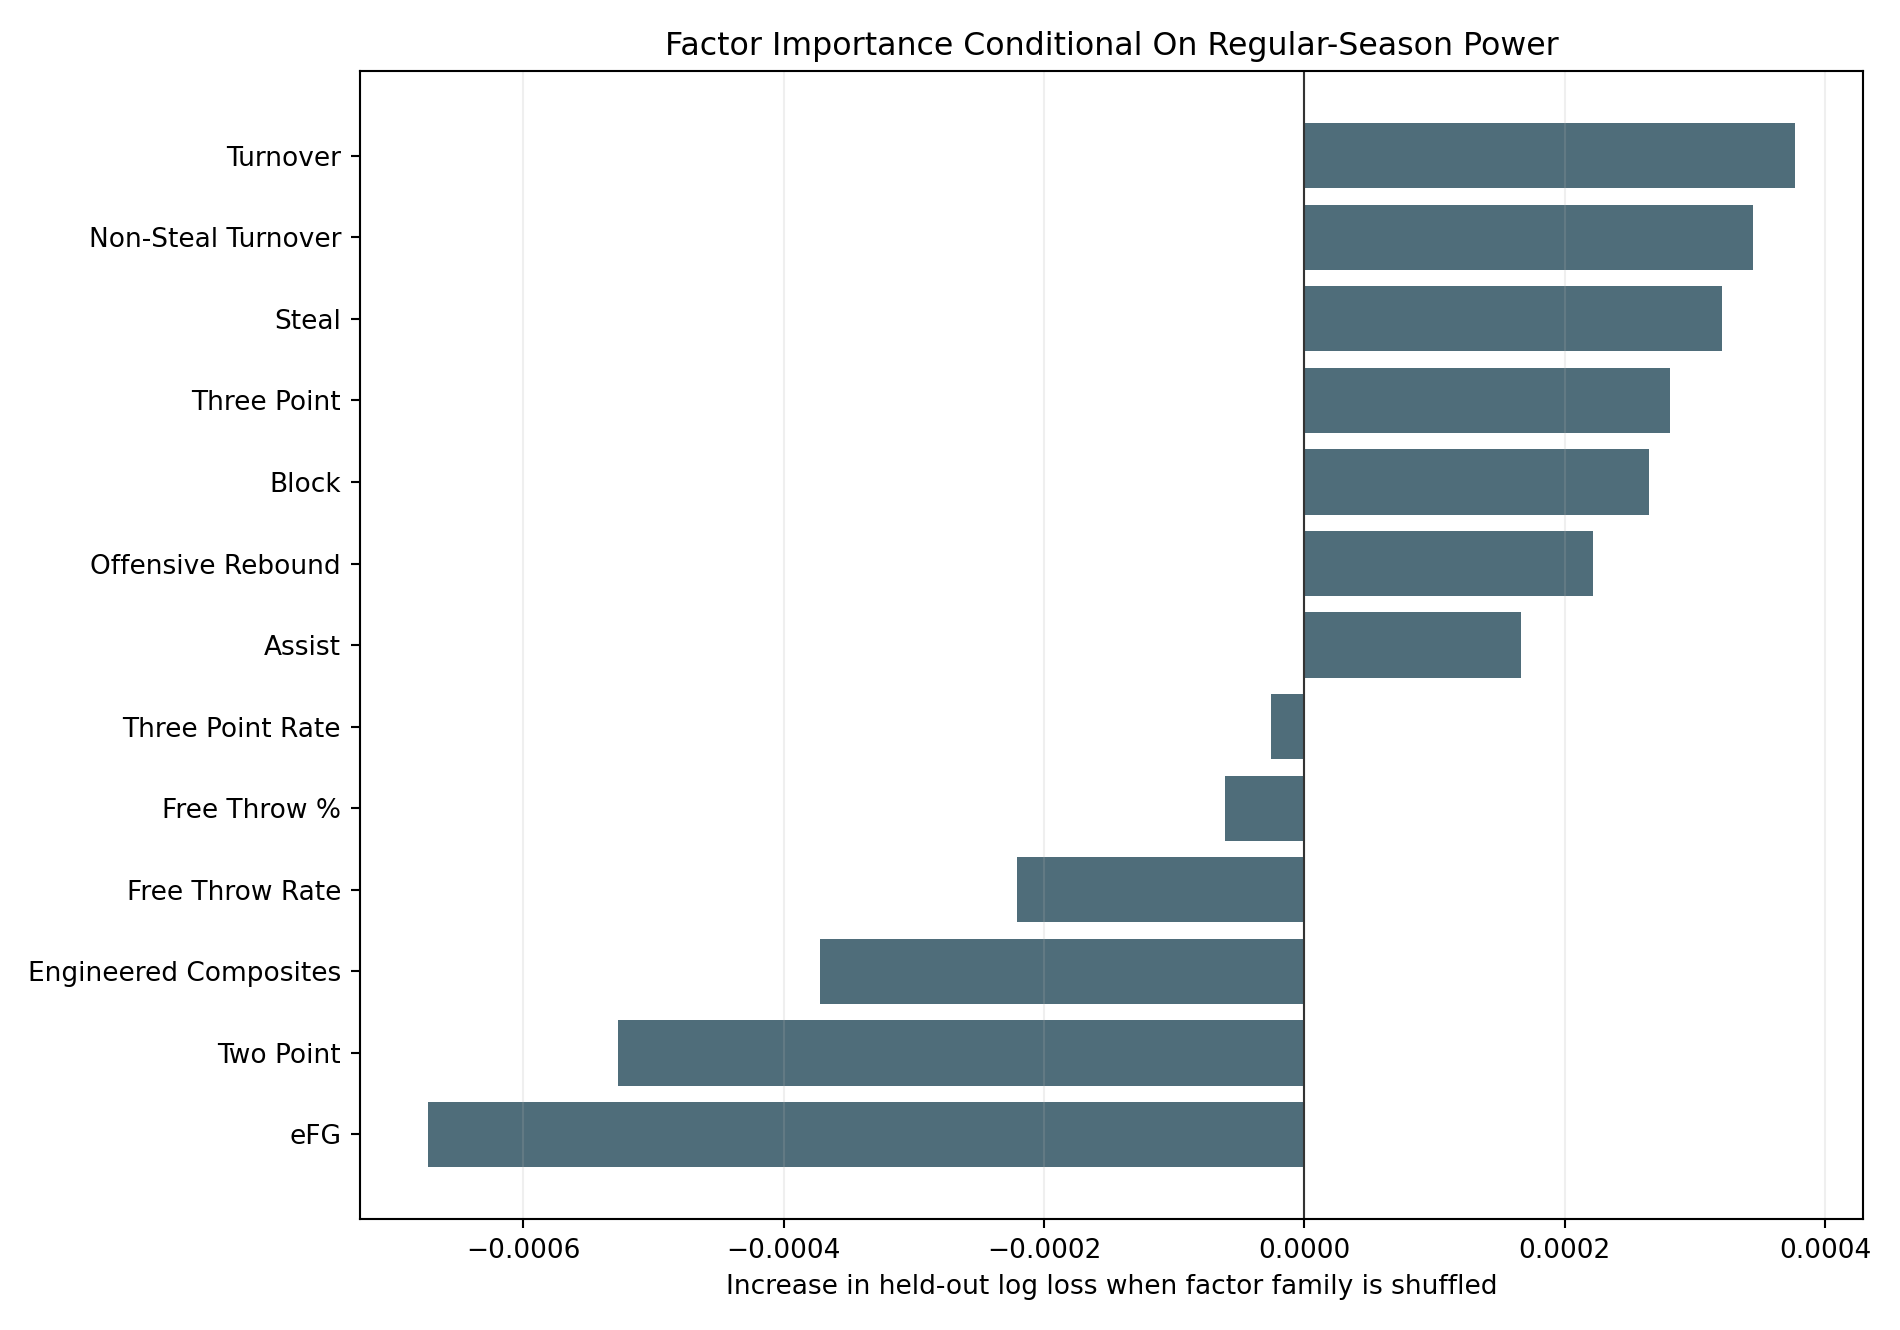

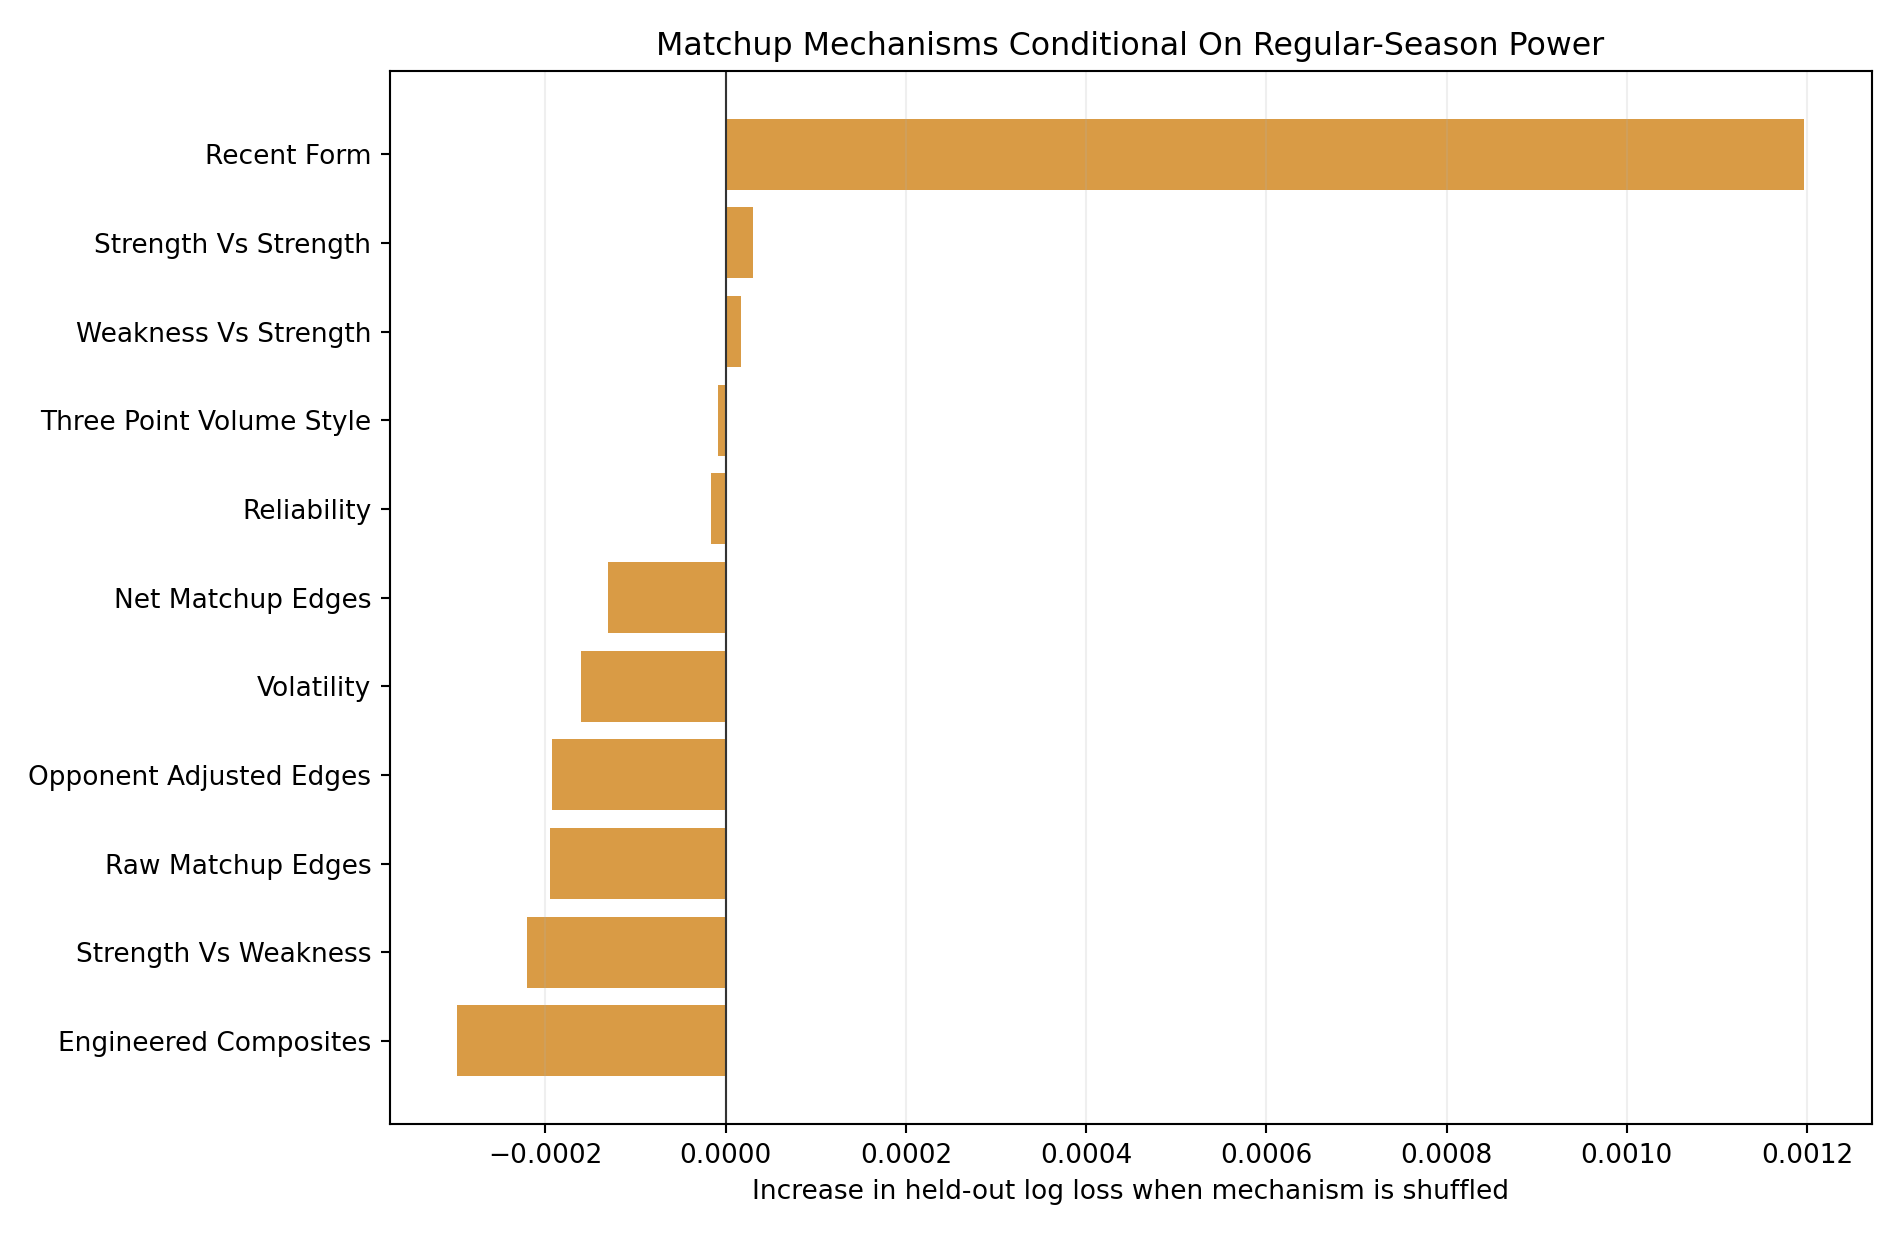

In [10]:
display(Image(filename=str(FIGURES / "power_matchup_model_comparison.png")))
display(Image(filename=str(FIGURES / "conditional_factor_importance.png")))
display(Image(filename=str(FIGURES / "conditional_matchup_mechanism_importance.png")))

## 9. Strength Matchups

These descriptive held-out rates compare strong and weak offenses with strong
and weak defenses. Cells with fewer than ten games are suppressed.

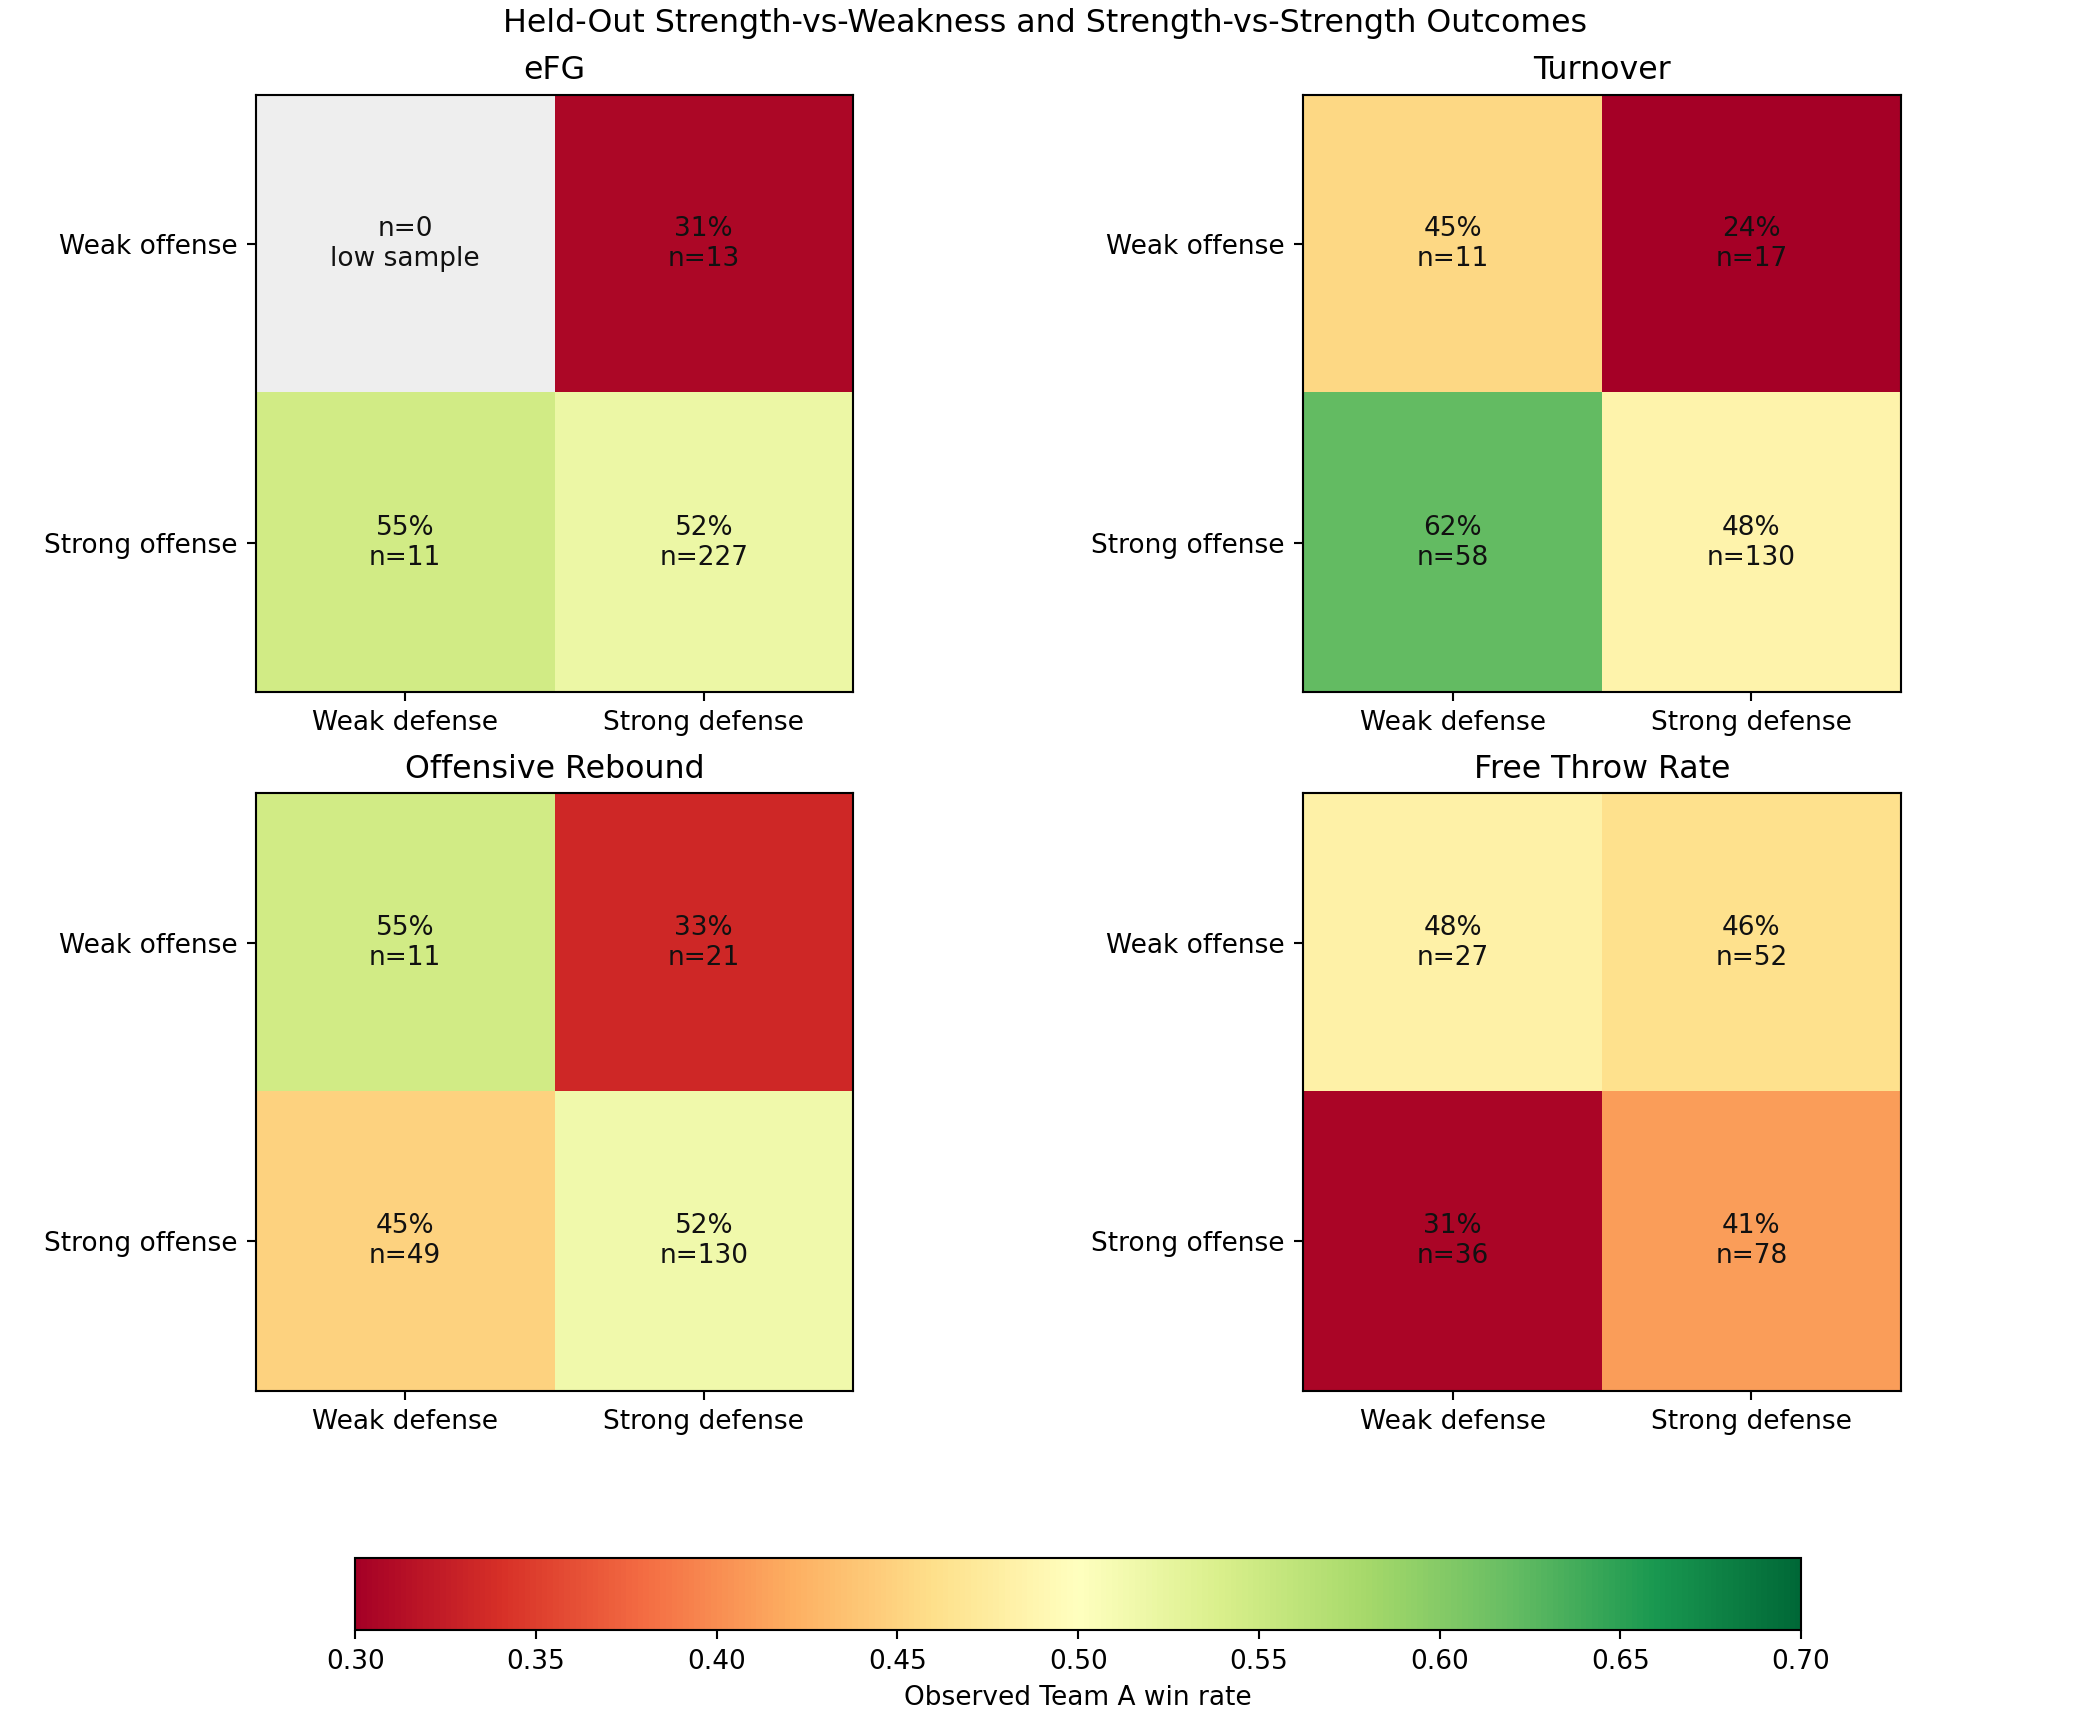

In [11]:
display(Image(filename=str(FIGURES / "matchup_quadrants.png")))

## 10. Detailed Results

Seeds appear only in the post-prediction upset diagnostic and never enter the
model. Permutation importance measures predictive reliance, not causality.

In [12]:
feature_importance = pd.read_csv(REPORTS / "feature_importance.csv")
group_importance = pd.read_csv(REPORTS / "group_importance.csv")
interaction_importance = pd.read_csv(REPORTS / "interaction_importance.csv")
hyperparameter_tuning = pd.read_csv(REPORTS / "hyperparameter_tuning.csv")
rolling_validation = pd.read_csv(REPORTS / "rolling_validation.csv")
upset_analysis = pd.read_csv(REPORTS / "upset_analysis.csv")
conditional_factor_importance = pd.read_csv(REPORTS / "conditional_factor_importance.csv")
conditional_mechanisms = pd.read_csv(REPORTS / "conditional_matchup_mechanism_importance.csv")
channel_importance = pd.read_csv(REPORTS / "channel_importance.csv")

display(feature_importance.head(20))
display(group_importance.head(20))
display(interaction_importance.head(20))
display(upset_analysis)
display(channel_importance)
display(conditional_factor_importance.head(20))
display(conditional_mechanisms.head(20))
rolling_validation[rolling_validation["model"].eq(metrics["selected_model"])]

,feature,family,importance_mean,importance_std,importance_low,importance_high,positive_fraction,positive_season_fraction,rank
0,efg_opponent_adjusted_matchup_edge,efg,0.006958,0.012582,-0.018077,0.029673,0.716667,0.833333,1
1,two_point_opponent_adjusted_matchup_edge,two_point,0.005301,0.009946,-0.012306,0.021446,0.683333,0.833333,2
2,offensive_rebound_opponent_adjusted_matchup_edge,offensive_rebound,0.005168,0.016378,-0.024814,0.040343,0.616667,0.666667,3
3,nonsteal_turnover_net_weakness_vs_strength,nonsteal_turnover,0.003258,0.006731,-0.008041,0.016086,0.658333,1.000000,4
4,offensive_rebound_net_strength_vs_strength,offensive_rebound,0.002989,0.004269,-0.004671,0.012334,0.766667,1.000000,5
5,free_throw_rate_net_strength_vs_weakness,free_throw_rate,0.002839,0.003161,-0.002441,0.009114,0.808333,1.000000,6
6,block_opponent_adjusted_matchup_edge,block,0.002247,0.004514,-0.005239,0.012275,0.666667,1.000000,7
7,free_throw_pct_net_strength_vs_strength,free_throw_pct,0.002190,0.005131,-0.009375,0.012347,0.708333,0.666667,8
8,turnover_opponent_adjusted_matchup_edge,turnover,0.002108,0.007220,-0.011712,0.014025,0.641667,0.666667,9
9,offensive_rebound_recent_form_edge,offensive_rebound,0.001862,0.006622,-0.011414,0.012709,0.633333,0.833333,10


,model,factor_group,feature_count,importance_mean,importance_std,positive_fraction
0,decision_tree,engineered_composites,17,0.024291,0.013697,0.966667
1,decision_tree,nonsteal_turnover,7,0.002286,0.003590,0.766667
2,decision_tree,three_point,7,0.001946,0.001934,0.766667
3,decision_tree,assist,7,0.001025,0.001036,0.833333
4,decision_tree,turnover,7,0.000000,0.000000,0.000000
5,decision_tree,block,7,0.000000,0.000000,0.000000
6,decision_tree,three_point_rate,4,0.000000,0.000000,0.000000
7,decision_tree,offensive_rebound,7,-0.000155,0.001812,0.566667
8,decision_tree,two_point,7,-0.001148,0.007516,0.400000
9,decision_tree,free_throw_rate,7,-0.001292,0.002935,0.266667


,model,factor_group,feature_count,importance_mean,importance_std,positive_fraction
0,decision_tree,engineered_composites,11,0.024418,0.013387,0.966667
1,decision_tree,opponent_adjusted_edges,11,0.003951,0.011636,0.600000
2,decision_tree,weakness_vs_strength,11,0.002821,0.003288,0.866667
3,decision_tree,strength_vs_strength,12,0.000963,0.001228,0.700000
4,decision_tree,three_point_volume_style,2,0.000000,0.000000,0.000000
5,decision_tree,reliability,1,0.000000,0.000000,0.000000
6,decision_tree,volatility,2,0.000000,0.000000,0.000000
7,decision_tree,net_matchup_edges,11,-0.000661,0.002988,0.433333
8,decision_tree,strength_vs_weakness,12,-0.001023,0.006701,0.433333
9,decision_tree,recent_form,12,-0.007044,0.004344,0.033333


,segment,games,accuracy,mean_confidence
0,actual_upsets,113,0.283186,0.668172
1,favorite_wins,288,0.809028,0.696386
2,all_seeded_games,401,0.660848,0.688436


,channel,stacker_coefficient,incremental_log_loss_gain_over_other_channel
0,regular_season_power,0.837129,0.012706
1,four_factors_matchups,0.090433,0.004106


,model,factor_group,feature_count,importance_mean,importance_std,positive_fraction
0,two_channel_stack,turnover,7,0.000377,0.000272,0.900
1,two_channel_stack,nonsteal_turnover,7,0.000345,0.000271,0.925
2,two_channel_stack,steal,7,0.000321,0.000484,0.775
3,two_channel_stack,three_point,7,0.000281,0.000192,0.925
4,two_channel_stack,block,7,0.000265,0.000137,0.975
5,two_channel_stack,offensive_rebound,7,0.000222,0.000657,0.600
6,two_channel_stack,assist,7,0.000167,0.000309,0.700
7,two_channel_stack,three_point_rate,4,-0.000026,0.000067,0.400
8,two_channel_stack,free_throw_pct,7,-0.000061,0.000301,0.475
9,two_channel_stack,free_throw_rate,7,-0.000221,0.000179,0.125


,model,factor_group,feature_count,importance_mean,importance_std,positive_fraction
0,two_channel_stack,recent_form,12,0.001197,0.000559,0.975
1,two_channel_stack,strength_vs_strength,12,0.000031,0.000262,0.500
2,two_channel_stack,weakness_vs_strength,11,0.000017,0.000284,0.525
3,two_channel_stack,three_point_volume_style,2,-0.000008,0.000030,0.400
4,two_channel_stack,reliability,1,-0.000016,0.000074,0.400
5,two_channel_stack,net_matchup_edges,11,-0.000131,0.000265,0.225
6,two_channel_stack,volatility,2,-0.000160,0.000070,0.000
7,two_channel_stack,opponent_adjusted_edges,11,-0.000193,0.000690,0.375
8,two_channel_stack,raw_matchup_edges,13,-0.000195,0.000260,0.225
9,two_channel_stack,strength_vs_weakness,12,-0.000221,0.000284,0.275


,model,season,games,accuracy,brier,log_loss,roc_auc
0,regularized_logistic,2017,67,0.746269,0.186290,0.545710,0.784821
5,regularized_logistic,2018,67,0.656716,0.210875,0.624151,0.733929
10,regularized_logistic,2019,67,0.716418,0.181580,0.536954,0.813889
15,regularized_logistic,2021,66,0.681818,0.218440,0.648008,0.740741
20,regularized_logistic,2022,67,0.611940,0.245091,0.701340,0.681488
25,regularized_logistic,2023,67,0.582090,0.228912,0.646136,0.663063


## 11. Saved Summaries

In [13]:
display(Markdown((REPORTS / "summary.md").read_text()))
display(Markdown((REPORTS / "power_matchup_summary.md").read_text()))

# Trustworthy Four Factors + Misc Importance Analysis

## Data timing

Features are computed only from NCAA regular-season detailed box scores. Tournament results are stored separately, so the feature snapshot is confirmed pre-tournament rather than inferred from a season-end KenPom page.

## Selected model

- Model: Regularized Logistic
- Held-out accuracy: 0.661
- Held-out ROC AUC: 0.731
- Held-out log loss: 0.616
- Accuracy 95% Wilson interval: 0.613-0.705
- Importance interpretation gate passed: True
- Model selection basis: hyperparameters and model family selected only by pre-2017 expanding-window cross-validation; 2017-2023 is evaluation-only

## Most important features

- eFG Opponent Adjusted Matchup Edge: 0.0070 mean held-out log-loss increase; positive in 83% of seasons
- Two Point Opponent Adjusted Matchup Edge: 0.0053 mean held-out log-loss increase; positive in 83% of seasons
- Offensive Rebound Opponent Adjusted Matchup Edge: 0.0052 mean held-out log-loss increase; positive in 67% of seasons
- Non-Steal Turnover Net Weakness Vs Strength: 0.0033 mean held-out log-loss increase; positive in 100% of seasons
- Offensive Rebound Net Strength Vs Strength: 0.0030 mean held-out log-loss increase; positive in 100% of seasons
- Free Throw Rate Net Strength Vs Weakness: 0.0028 mean held-out log-loss increase; positive in 100% of seasons
- Block Opponent Adjusted Matchup Edge: 0.0022 mean held-out log-loss increase; positive in 100% of seasons
- Free Throw % Net Strength Vs Strength: 0.0022 mean held-out log-loss increase; positive in 67% of seasons

## Factor-group consensus

- Engineered Composites: 0.0330
- Offensive Rebound: 0.0107
- eFG: 0.0095
- Two Point: 0.0079
- Non-Steal Turnover: 0.0046
- Turnover: 0.0024
- Block: 0.0017
- Free Throw %: 0.0015
- Steal: 0.0015
- Three Point: 0.0005
- Assist: 0.0004
- Free Throw Rate: -0.0001
- Three Point Rate: -0.0001

## Matchup-mechanism importance

- Opponent Adjusted Edges: 0.0257
- Engineered Composites: 0.0231
- Weakness Vs Strength: 0.0069
- Recent Form: 0.0049
- Net Matchup Edges: 0.0029
- Strength Vs Strength: 0.0017
- Strength Vs Weakness: 0.0009
- Three Point Volume Style: 0.0000
- Reliability: -0.0002
- Volatility: -0.0004
- Raw Matchup Edges: -0.0033

## Upset behavior

- Actual Upsets: 0.283 accuracy across 113 games
- Favorite Wins: 0.809 accuracy across 288 games
- All Seeded Games: 0.661 accuracy across 401 games

## Interpretation guardrails

Permutation importance measures predictive reliance, not causality. Correlated engineered features share credit, which is why the grouped chart and cross-model range are more reliable than a single feature's exact rank.
Tournament seeds, KenPom rank, net rating, luck, and adjusted efficiency are excluded from the factor-only model. The separate two-channel report uses an internally estimated regular-season scoring-efficiency baseline; seeds are used only after prediction to label upset evaluation segments.


# Power Baseline + Interpretable Matchup Model

## Architecture

The model keeps opponent-adjusted regular-season scoring power in one channel and Four Factors matchup interactions in another. KenPom rank, net rating, luck, tournament seed, and season-end KenPom values are not inputs.

Regular-season games used to estimate pre-tournament team strength: **107,634**.

## Held-out comparison

- Two Channel Stack: 0.653 accuracy, 0.730 ROC AUC, 0.602 log loss
- Regular Season Power Only: 0.658 accuracy, 0.727 ROC AUC, 0.606 log loss
- Factor Only: 0.656 accuracy, 0.732 ROC AUC, 0.615 log loss

## Channel weights

- Regular-season power coefficient: 0.837
- Four Factors matchup coefficient: 0.090

These coefficients describe the final stack, not feature importance. The factor-only and conditional permutation reports remain the interpretation surfaces.

## Conditional factor importance

- Turnover: 0.0004 held-out log-loss increase
- Non-Steal Turnover: 0.0003 held-out log-loss increase
- Steal: 0.0003 held-out log-loss increase
- Three Point: 0.0003 held-out log-loss increase
- Block: 0.0003 held-out log-loss increase
- Offensive Rebound: 0.0002 held-out log-loss increase
- Assist: 0.0002 held-out log-loss increase
- Three Point Rate: -0.0000 held-out log-loss increase

## Conditional matchup mechanisms

- Recent Form: 0.0012 held-out log-loss increase
- Strength Vs Strength: 0.0000 held-out log-loss increase
- Weakness Vs Strength: 0.0000 held-out log-loss increase
- Three Point Volume Style: -0.0000 held-out log-loss increase
- Reliability: -0.0000 held-out log-loss increase
- Net Matchup Edges: -0.0001 held-out log-loss increase
- Volatility: -0.0002 held-out log-loss increase
- Opponent Adjusted Edges: -0.0002 held-out log-loss increase

## Data boundary

Current official-format local tournament outcomes end in 2023; 2024-2025 remain unavailable without a current competition-data download.
